# 금융상품 데이터 EDA (2026-08-24 교체 데이터)

이 노트북은 **노트북과 같은 폴더**에 있는 새 데이터 파일을 대상으로 실행합니다.

- `prbd01n001`: 국내채권
- `prfd01n001`: 공모펀드
- `pref01n001`: 국내 ETF
- `pref02n001`: 해외 ETF

새 배포 형식인 `*_data.xlsx`의 `data` 시트와 `*_schema.xlsx`의 `schema` 시트를 사용합니다.  
전체 상품군의 크기·결측·중복·스키마 정합성을 확인하고, 상품군별 컬럼 프로파일·분포·상관관계·범주 빈도·금융지표 후보를 살펴봅니다.

`NROWS=None`은 전체 데이터를 읽습니다. 빠른 테스트가 필요하면 설정 셀에서 `NROWS=1000`처럼 바꾸세요.

In [23]:
from pathlib import Path
import math
import re
import warnings

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from pandas.api.types import is_datetime64_any_dtype, is_numeric_dtype

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["axes.unicode_minus"] = False

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in ["AppleGothic", "Malgun Gothic", "NanumGothic", "DejaVu Sans"]:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break

## 1. 분석 설정 및 파일 확인

In [24]:
# 노트북이 데이터 폴더 안에 있으므로 현재 폴더만 사용합니다.
DATA_DIR = Path(".").resolve()
OUTPUT_DIR = DATA_DIR / "eda_output"

PRODUCTS = {
    "prbd01n001": "국내채권",
    "prfd01n001": "공모펀드",
    "pref01n001": "국내 ETF",
    "pref02n001": "해외 ETF",
}

DATA_SHEET = "data"
SCHEMA_SHEET = "schema"

# None: 전체 행, 정수: 해당 행 수만 읽기
NROWS = None

MAX_HISTOGRAM_COLUMNS = 12
MAX_CORRELATION_COLUMNS = 12
MAX_CATEGORY_COLUMNS = 6
RANDOM_STATE = 42
SAVE_PLOTS = True

expected_files = []
for product_code in PRODUCTS:
    expected_files.extend([
        DATA_DIR / f"{product_code}_data.xlsx",
        DATA_DIR / f"{product_code}_schema.xlsx",
    ])

missing_files = [path.name for path in expected_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "현재 폴더에서 다음 파일을 찾지 못했습니다: " + ", ".join(missing_files)
    )

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

file_catalog = pd.DataFrame([
    {
        "product_code": product_code,
        "product_name": product_name,
        "data_file": f"{product_code}_data.xlsx",
        "schema_file": f"{product_code}_schema.xlsx",
        "data_size_mb": round(
            (DATA_DIR / f"{product_code}_data.xlsx").stat().st_size / 1024**2,
            2,
        ),
    }
    for product_code, product_name in PRODUCTS.items()
])

print(f"데이터 폴더: {DATA_DIR}")
print(f"결과 폴더: {OUTPUT_DIR}")
display(file_catalog)

데이터 폴더: /Users/jaeuhnjin/Desktop/미래에셋 공모전/ai-festival2026_금융상품Agent_DtataSet260824
결과 폴더: /Users/jaeuhnjin/Desktop/미래에셋 공모전/ai-festival2026_금융상품Agent_DtataSet260824/eda_output


,product_code,product_name,data_file,schema_file,data_size_mb
0,prbd01n001,국내채권,prbd01n001_data.xlsx,prbd01n001_schema.xlsx,5.6500
1,prfd01n001,공모펀드,prfd01n001_data.xlsx,prfd01n001_schema.xlsx,8.7100
2,pref01n001,국내 ETF,pref01n001_data.xlsx,pref01n001_schema.xlsx,0.9100
3,pref02n001,해외 ETF,pref02n001_data.xlsx,pref02n001_schema.xlsx,2.0100


## 2. 로드·전처리·프로파일 함수

In [25]:
DATE_PATTERN = re.compile(r"(?:^|_)(?:dt|date)$", flags=re.IGNORECASE)
ID_PATTERN = re.compile(
    r"(?:^|_)(?:id|no|cd|ccd|gcd|tcd|pcd|cik)(?:$|_)",
    flags=re.IGNORECASE,
)
FINANCE_PATTERN = re.compile(
    r"yield|ern_r|return|aum|nast|net_tamt|price|nav|irt|dur|cov|risk|"
    r"rate|(?:^|_)rt$|rwrd_r|cmst_rt|(?:^|_)[bs]bpr$",
    flags=re.IGNORECASE,
)
DATE_SENTINELS = {"99991231", "99991231000000", "00000000", "0"}


def read_schema(product_code):
    """새 schema 시트를 읽고 분석용 표준 컬럼명으로 정리합니다."""
    schema_file = DATA_DIR / f"{product_code}_schema.xlsx"
    schema = pd.read_excel(
        schema_file,
        sheet_name=SCHEMA_SHEET,
        engine="openpyxl",
    )
    schema.columns = schema.columns.astype(str).str.strip()

    required = {"컬럼명", "데이터타입", "Nullable", "컬럼코멘트"}
    missing = required.difference(schema.columns)
    if missing:
        raise ValueError(
            f"{schema_file.name} 스키마 컬럼 누락: {sorted(missing)}"
        )

    schema = schema.rename(columns={
        "순번": "sequence",
        "컬럼명": "column",
        "데이터타입": "schema_type",
        "Nullable": "nullable",
        "컬럼코멘트": "description",
    })
    schema["column"] = schema["column"].astype("string").str.strip()
    schema["schema_type"] = schema["schema_type"].astype("string").str.strip()
    return schema


def parse_date_columns(df):
    """이름이 *_dt 또는 *_date인 컬럼을 날짜 성공률에 따라 변환합니다."""
    result = df.copy()

    for column in result.columns:
        if not DATE_PATTERN.search(str(column)):
            continue

        raw = (
            result[column]
            .astype("string")
            .str.strip()
            .str.replace(r"\.0$", "", regex=True)
        )
        cleaned = raw.mask(raw.isin(DATE_SENTINELS))

        parsed = pd.Series(pd.NaT, index=result.index, dtype="datetime64[ns]")
        mask_8 = cleaned.str.fullmatch(r"\d{8}", na=False)
        mask_14 = cleaned.str.fullmatch(r"\d{14}", na=False)
        mask_other = cleaned.notna() & ~(mask_8 | mask_14)

        parsed.loc[mask_8] = pd.to_datetime(
            cleaned.loc[mask_8], format="%Y%m%d", errors="coerce"
        )
        parsed.loc[mask_14] = pd.to_datetime(
            cleaned.loc[mask_14], format="%Y%m%d%H%M%S", errors="coerce"
        )
        parsed.loc[mask_other] = pd.to_datetime(
            cleaned.loc[mask_other], errors="coerce"
        )

        denominator = max(int(cleaned.notna().sum()), 1)
        conversion_rate = parsed.notna().sum() / denominator
        if conversion_rate >= 0.70:
            result[column] = parsed

    return result


def read_product(product_code):
    """스키마의 text 타입을 보존하면서 한 상품군의 데이터를 읽습니다."""
    schema = read_schema(product_code)
    data_file = DATA_DIR / f"{product_code}_data.xlsx"

    text_columns = schema.loc[
        schema["schema_type"].str.lower().eq("text"), "column"
    ].tolist()
    dtype_map = {column: "string" for column in text_columns}

    frame = pd.read_excel(
        data_file,
        sheet_name=DATA_SHEET,
        engine="openpyxl",
        nrows=NROWS,
        dtype=dtype_map,
    )
    frame.columns = frame.columns.astype(str).str.strip()
    frame = parse_date_columns(frame)

    data_only = sorted(set(frame.columns).difference(schema["column"]))
    schema_only = sorted(set(schema["column"]).difference(frame.columns))
    if data_only or schema_only:
        raise ValueError(
            f"{product_code} 데이터/스키마 불일치 - "
            f"data_only={data_only}, schema_only={schema_only}"
        )

    return frame, schema


def create_column_profile(df, schema):
    """스키마 설명과 결측·고유값·기초통계를 합친 컬럼 프로파일입니다."""
    records = []

    for column in df.columns:
        series = df[column]
        non_null = series.dropna()
        record = {
            "column": column,
            "pandas_dtype": str(series.dtype),
            "non_null_count": int(series.notna().sum()),
            "missing_count": int(series.isna().sum()),
            "missing_pct": round(series.isna().mean() * 100, 2),
            "unique_count": int(series.nunique(dropna=True)),
            "sample_values": " | ".join(
                non_null.astype(str).drop_duplicates().head(3).tolist()
            ),
        }

        if is_numeric_dtype(series):
            numeric = pd.to_numeric(series, errors="coerce").replace(
                [np.inf, -np.inf], np.nan
            )
            record.update({
                "mean": numeric.mean(),
                "std": numeric.std(),
                "min": numeric.min(),
                "q1": numeric.quantile(0.25),
                "median": numeric.median(),
                "q3": numeric.quantile(0.75),
                "max": numeric.max(),
            })
        elif is_datetime64_any_dtype(series):
            record.update({"min": series.min(), "max": series.max()})

        records.append(record)

    profile = pd.DataFrame(records)
    schema_columns = [
        "column", "sequence", "schema_type", "nullable", "description"
    ]
    schema_columns = [c for c in schema_columns if c in schema.columns]
    profile = profile.merge(schema[schema_columns], on="column", how="left")

    preferred_order = [
        "column", "description", "schema_type", "pandas_dtype", "nullable",
        "non_null_count", "missing_count", "missing_pct", "unique_count",
        "mean", "std", "min", "q1", "median", "q3", "max",
        "sample_values", "sequence",
    ]
    return profile[[c for c in preferred_order if c in profile.columns]]


def is_analysis_numeric(column, series):
    """식별자·상수 컬럼을 제외한 실제 분석용 숫자 컬럼만 고릅니다."""
    if not is_numeric_dtype(series) or is_datetime64_any_dtype(series):
        return False
    if ID_PATTERN.search(str(column)):
        return False
    return series.notna().any() and series.nunique(dropna=True) > 1


def quality_flags(df):
    missing_pct = df.isna().mean().mul(100)
    return pd.DataFrame({
        "항목": [
            "전체 결측 컬럼",
            "결측률 90% 이상 컬럼",
            "단일값 컬럼(결측 제외)",
        ],
        "개수": [
            int((missing_pct == 100).sum()),
            int((missing_pct >= 90).sum()),
            int(sum(df[c].nunique(dropna=True) <= 1 for c in df.columns)),
        ],
    })


def finance_summary(df):
    columns = [
        column for column in df.columns
        if is_analysis_numeric(column, df[column])
        and FINANCE_PATTERN.search(str(column))
    ]
    if not columns:
        return pd.DataFrame()
    return (
        df[columns]
        .replace([np.inf, -np.inf], np.nan)
        .describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])
        .T
        .sort_values("count", ascending=False)
    )

In [26]:
def plot_product_eda(product_code, df):
    """상품군별 결측·숫자 분포·상관관계·범주 빈도를 표시하고 저장합니다."""
    product_name = PRODUCTS[product_code]
    product_output_dir = OUTPUT_DIR / product_code
    product_output_dir.mkdir(parents=True, exist_ok=True)

    missing = df.isna().mean().mul(100).sort_values(ascending=False)
    missing = missing[missing > 0]

    if missing.empty:
        print("결측치가 없습니다.")
    else:
        plt.figure(figsize=(10, max(5, len(missing) * 0.30)))
        sns.barplot(x=missing.values, y=missing.index, color="#356AE6")
        plt.xlabel("결측률 (%)")
        plt.ylabel("")
        plt.title(f"{product_name} - 결측률 상위 컬럼")
        plt.xlim(0, 100)
        plt.tight_layout()
        if SAVE_PLOTS:
            plt.savefig(product_output_dir / "missing_values.png", dpi=160)
        plt.show()
        plt.close()

    numeric_columns = [
        column for column in df.columns
        if is_analysis_numeric(column, df[column])
    ]
    numeric_columns = sorted(
        numeric_columns,
        key=lambda column: df[column].notna().sum(),
        reverse=True,
    )[:MAX_HISTOGRAM_COLUMNS]

    if numeric_columns:
        ncols = 3
        nrows = math.ceil(len(numeric_columns) / ncols)
        fig, axes = plt.subplots(
            nrows, ncols, figsize=(15, 4 * nrows), squeeze=False
        )

        for axis, column in zip(axes.flat, numeric_columns):
            values = pd.to_numeric(df[column], errors="coerce").replace(
                [np.inf, -np.inf], np.nan
            ).dropna()
            if len(values) > 100_000:
                values = values.sample(100_000, random_state=RANDOM_STATE)
            sns.histplot(values, bins=40, ax=axis, color="#356AE6")
            axis.set_title(column)
            axis.set_xlabel("")

        for axis in axes.flat[len(numeric_columns):]:
            axis.axis("off")

        fig.suptitle(f"{product_name} - 숫자형 분포", fontsize=16)
        plt.tight_layout()
        if SAVE_PLOTS:
            plt.savefig(
                product_output_dir / "numeric_distributions.png", dpi=160
            )
        plt.show()
        plt.close()

    correlation_columns = numeric_columns[:MAX_CORRELATION_COLUMNS]
    if len(correlation_columns) >= 2:
        correlation_sample = df[correlation_columns].replace(
            [np.inf, -np.inf], np.nan
        )
        if len(correlation_sample) > 50_000:
            correlation_sample = correlation_sample.sample(
                50_000, random_state=RANDOM_STATE
            )

        correlation = correlation_sample.corr(method="spearman")
        plt.figure(figsize=(12, 10))
        sns.heatmap(
            correlation,
            cmap="RdBu_r",
            center=0,
            vmin=-1,
            vmax=1,
            square=True,
        )
        plt.title(f"{product_name} - Spearman 상관관계")
        plt.tight_layout()
        if SAVE_PLOTS:
            plt.savefig(product_output_dir / "correlation_heatmap.png", dpi=160)
        plt.show()
        plt.close()

    categorical_columns = df.select_dtypes(
        include=["object", "string", "category", "bool"]
    ).columns
    category_candidates = [
        column for column in categorical_columns
        if 2 <= df[column].nunique(dropna=True) <= 30
    ]
    category_candidates = sorted(
        category_candidates,
        key=lambda column: df[column].notna().sum(),
        reverse=True,
    )[:MAX_CATEGORY_COLUMNS]

    if category_candidates:
        fig, axes = plt.subplots(
            len(category_candidates),
            1,
            figsize=(12, 4 * len(category_candidates)),
            squeeze=False,
        )

        for axis, column in zip(axes.flat, category_candidates):
            counts = (
                df[column]
                .fillna("(결측)")
                .astype(str)
                .value_counts()
                .head(10)
                .sort_values()
            )
            sns.barplot(
                x=counts.values,
                y=counts.index,
                ax=axis,
                color="#2A9D8F",
            )
            axis.set_title(column)
            axis.set_xlabel("건수")
            axis.set_ylabel("")

        plt.tight_layout()
        if SAVE_PLOTS:
            plt.savefig(
                product_output_dir / "categorical_frequencies.png", dpi=160
            )
        plt.show()
        plt.close()

## 3. 전체 데이터 로드 및 품질 요약

In [27]:
datasets = {}
schemas = {}
profiles = {}
overview_records = []

for product_code, product_name in PRODUCTS.items():
    print(f"읽는 중: {product_name} ({product_code})")
    frame, schema = read_product(product_code)
    profile = create_column_profile(frame, schema)

    datasets[product_code] = frame
    schemas[product_code] = schema
    profiles[product_code] = profile

    total_cells = max(frame.shape[0] * frame.shape[1], 1)
    overview_records.append({
        "product_code": product_code,
        "product_name": product_name,
        "rows": len(frame),
        "columns": frame.shape[1],
        "duplicate_rows": int(frame.duplicated().sum()),
        "missing_cells": int(frame.isna().sum().sum()),
        "missing_cells_pct": round(
            frame.isna().sum().sum() / total_cells * 100, 2
        ),
        "memory_mb": round(
            frame.memory_usage(deep=True).sum() / 1024**2, 2
        ),
        "schema_columns": len(schema),
        "schema_match": len(frame.columns) == len(schema),
    })

    profile.to_csv(
        OUTPUT_DIR / f"{product_code}_column_profile.csv",
        index=False,
        encoding="utf-8-sig",
    )

overview = pd.DataFrame(overview_records)
overview.to_csv(
    OUTPUT_DIR / "dataset_overview.csv",
    index=False,
    encoding="utf-8-sig",
)

display(overview)

읽는 중: 국내채권 (prbd01n001)
읽는 중: 공모펀드 (prfd01n001)
읽는 중: 국내 ETF (pref01n001)
읽는 중: 해외 ETF (pref02n001)


,product_code,product_name,rows,columns,duplicate_rows,missing_cells,missing_cells_pct,memory_mb,schema_columns,schema_match
0,prbd01n001,국내채권,21882,58,0,297175,23.4200,51.6100,58,True
1,prfd01n001,공모펀드,23676,75,0,609201,34.3100,91.0800,75,True
2,pref01n001,국내 ETF,1780,98,0,36119,20.7100,6.3500,98,True
3,pref02n001,해외 ETF,6037,49,0,42014,14.2000,12.7300,49,True


## 4. 국내채권 (`prbd01n001`)

In [28]:
SELECTED_PRODUCT = "prbd01n001"
df = datasets[SELECTED_PRODUCT]

print(f"상품군: {PRODUCTS[SELECTED_PRODUCT]} ({SELECTED_PRODUCT})")
print(f"형태: {df.shape[0]:,}행 × {df.shape[1]:,}열")
display(quality_flags(df))
display(df.head())

상품군: 국내채권 (prbd01n001)
형태: 21,882행 × 58열


,항목,개수
0,전체 결측 컬럼,0
1,결측률 90% 이상 컬럼,13
2,단일값 컬럼(결측 제외),6


,after_tax_yield,applied_yield,avg_annual_tax_yield,bdbns_abl_chnl_nm,bdbns_abl_chnl_tcd,bd_inrt_tcd,bd_intp_tcd,bd_knd,bd_ofr_tcd,bd_tisu_a,buyable_quantity,buy_yield,corp_after_tax_yield,corp_pretax_yield,cov,crd_grd,crd_grd_dt,curr_cd,depo_equiv_yield_154,depo_equiv_yield_495,dirty,dur,eval_price,exg_close_price,exg_close_price_base_dt,exg_close_yield,exrt_grte_ern_r,exrt_grte_ern_r_tcd,exrt_rpy_r,info_base_dt,info_seq,isu_bal_amt,isu_dt,mat_dt,ndy_applied_yield,ndy_cov,ndy_dirty,ndy_dur,ndy_eval_price,pd_abrv_eng_nm,pd_abrv_nm,pd_ctry_cd,pd_eng_nm,pd_exg_mkt,pd_nm,pd_no,pd_pbcm,pd_pen_tr_yn,pd_risk_gcd,pd_risk_nm,pd_std_info_update,pref_tax_yield,remaining_days,sale_yield_base_dt,srfc_irt,std_pd_mcls_nm,std_pd_scls_nm,trade_price
0,NaN,3.7140,NaN,<NA>,<NA>,고정금리,이표채,유동화회사채,공모,10000000000,NaN,NaN,NaN,NaN,0.2915,AAA,2025-12-12,KRW,NaN,NaN,"9,994.1500",0.4990,"9,994.1500",0.0000,,0.0000,0.0000,99,100.0000,2026-08-21,1,"10,000,000,000.0000",2025-12-23,2027-02-23,3.7140,0.2893,"9,995.1500",0.4971,"9,995.1500",First 5G 84th SEC1-14,퍼스트파이브지84차유1-14,KR,First 5G Eighty Fourth Securitization Specialt...,장내,퍼스트파이브지제팔십사차유동화전문1-14,KR60143NEFC6,퍼스트파이브지제팔십사차유동화전문(,N,15,낮은위험(5등급),20260821,NaN,186.0000,NaT,3.1120,회사채,일반사채,NaN
1,NaN,3.8470,NaN,<NA>,<NA>,고정금리,이표채,일반지방공사채,공모,110000000000,NaN,NaN,NaN,NaN,1.6036,AAA,2024-10-25,KRW,NaN,NaN,"9,946.4500",1.1481,"9,946.4500",0.0000,,0.0000,0.0000,99,100.0000,2026-08-21,1,"110,000,000,000.0000",2024-10-25,2027-10-25,3.8470,1.5965,"9,947.4800",1.1471,"9,947.4800",GH24-10-83(T),경기주택도시공사24-10-83(지),KR,GYEONGGI HOUSING&URBAN DEVELOPMENT24-10-83(T) ...,장내,경기주택도시공사24-10-83(지),KR353601GEA5,경기주택도시공사,N,16,매우낮은위험(6등급),20260821,NaN,430.0000,NaT,3.1780,특수채,일반사채,NaN
2,NaN,4.4900,NaN,<NA>,<NA>,고정금리,이표채,MBS,공모,130000000000,NaN,NaN,NaN,NaN,62.2844,AAA,2015-06-02,KRW,NaN,NaN,"8,781.4400",7.3760,"8,781.4400",0.0000,,0.0000,0.0000,99,100.0000,2026-08-21,1,"130,000,000,000.0000",2015-06-02,2035-06-02,4.4900,61.2515,"8,782.5100",7.2910,"8,782.5100",KHFCMBS2015-11(1-8),주택금융공사MBS2015-11(1-8),KR,Korea Housing Finance CorporationMBS2015-11(1-...,장내,한국주택금융공사 MBS2015-11(1-8)(콜),KR354408G566,한국주택금융공사,N,16,매우낮은위험(6등급),20260821,NaN,"3,207.0000",NaT,2.6900,특수채,공사채,NaN
3,NaN,3.4520,NaN,<NA>,<NA>,고정금리,이표채,일반회사채,공모,110000000000,NaN,NaN,NaN,NaN,0.2429,AA+,2025-01-14,KRW,NaN,NaN,"10,007.5700",0.3918,"10,007.5700",0.0000,,0.0000,0.0000,99,100.0000,2026-08-21,1,"110,000,000,000.0000",2025-01-14,2027-01-14,3.4520,0.2384,"10,008.5000",0.3901,"10,008.5000",POSCO314-1,POSCO314-1,KR,POSCO314-1 ...,장내,POSCO314-1,KR6421091F14,(주)포스코,N,15,낮은위험(5등급),20260821,NaN,146.0000,NaT,2.8890,회사채,일반사채,NaN
4,NaN,4.0600,NaN,<NA>,<NA>,고정금리,이표채,MBS,공모,40000000000,NaN,NaN,NaN,NaN,15.9031,AAA,2016-04-08,KRW,NaN,NaN,"9,175.8700",3.6856,"9,175.8700",0.0000,,0.0000,0.0000,99,100.0000,2026-08-21,1,"40,000,000,000.0000",2016-04-08,2031-04-08,4.0600,14.2631,"9,176.8700",3.4553,"9,176.8700",KHFCMBS2016-8(1-7),주택금융공사MBS2016-8(1-7),KR,Korea Housing Finance CorporationMBS2016-8(1-7...,장내,한국주택금융공사 MBS2016-8(1-7)(콜),KR354407G642,한국주택금융공사,N,16,매우낮은위험(6등급),20260821,NaN,"1,691.0000",NaT,1.9090,특수채,공사채,NaN


### 컬럼 프로파일과 스키마 설명

In [29]:
profile_columns = [
    "column", "description", "schema_type", "pandas_dtype", "nullable",
    "missing_count", "missing_pct", "unique_count",
    "mean", "median", "min", "max", "sample_values",
]
profile_columns = [
    column for column in profile_columns
    if column in profiles[SELECTED_PRODUCT].columns
]

profile_view = (
    profiles[SELECTED_PRODUCT][profile_columns]
    .sort_values(["missing_pct", "unique_count"], ascending=[False, False])
    .reset_index(drop=True)
)
display(profile_view)

,column,description,schema_type,pandas_dtype,nullable,missing_count,missing_pct,unique_count,mean,median,min,max,sample_values
0,after_tax_yield,개인 세후 운용수익률,double precision,float64,YES,21248,97.1000,474,3.7865,3.8023,1.9244,5.7027,3.2464 | 3.361 | 3.7969
1,corp_after_tax_yield,법인 세후 투자수익률,double precision,float64,YES,21248,97.1000,469,3.7947,3.8023,1.9244,5.7027,3.2464 | 3.361 | 3.7969
2,pref_tax_yield,세금우대 세후 운용수익률,double precision,float64,YES,21248,97.1000,469,3.9313,3.9588,1.9859,5.8615,3.3255 | 3.441 | 3.882
3,corp_pretax_yield,법인 세전 투자수익률,double precision,float64,YES,21248,97.1000,447,4.1626,4.2071,2.0849,6.1172,3.4529 | 3.5699 | 4.019
4,depo_equiv_yield_495,은행환산수익률(세율 49.5 기준),double precision,float64,YES,21248,97.1000,445,5.8429,5.8865,1.2620,9.4750,5.523 | 5.739 | 6.545
5,depo_equiv_yield_154,예금환산수익률(세율 15.4 기준),double precision,float64,YES,21248,97.1000,415,4.4753,4.4940,2.2740,6.7400,3.837 | 3.972 | 4.488
6,trade_price,매매단가(표준투입단가),double precision,float64,YES,21248,97.1000,391,"9,662.1656","9,868.0000","5,570.0000","10,759.0000",10188.0 | 10059.0 | 9343.0
7,buy_yield,매수수익률/매수금리,double precision,float64,YES,21248,97.1000,348,3.9946,4.0450,2.0840,5.2900,3.42 | 3.52 | 3.825
8,buyable_quantity,매수가능수량,double precision,float64,YES,21248,97.1000,297,"543,120,858.0442",0.0000,0.0000,"18,587,504,000.0000",689393000.0 | 159859000.0 | 133785000.0
9,avg_annual_tax_yield,세후 연평균수익률,double precision,float64,YES,21248,97.1000,1,0.0000,0.0000,0.0000,0.0000,0.0


### 결측치·분포·상관관계·범주형 빈도

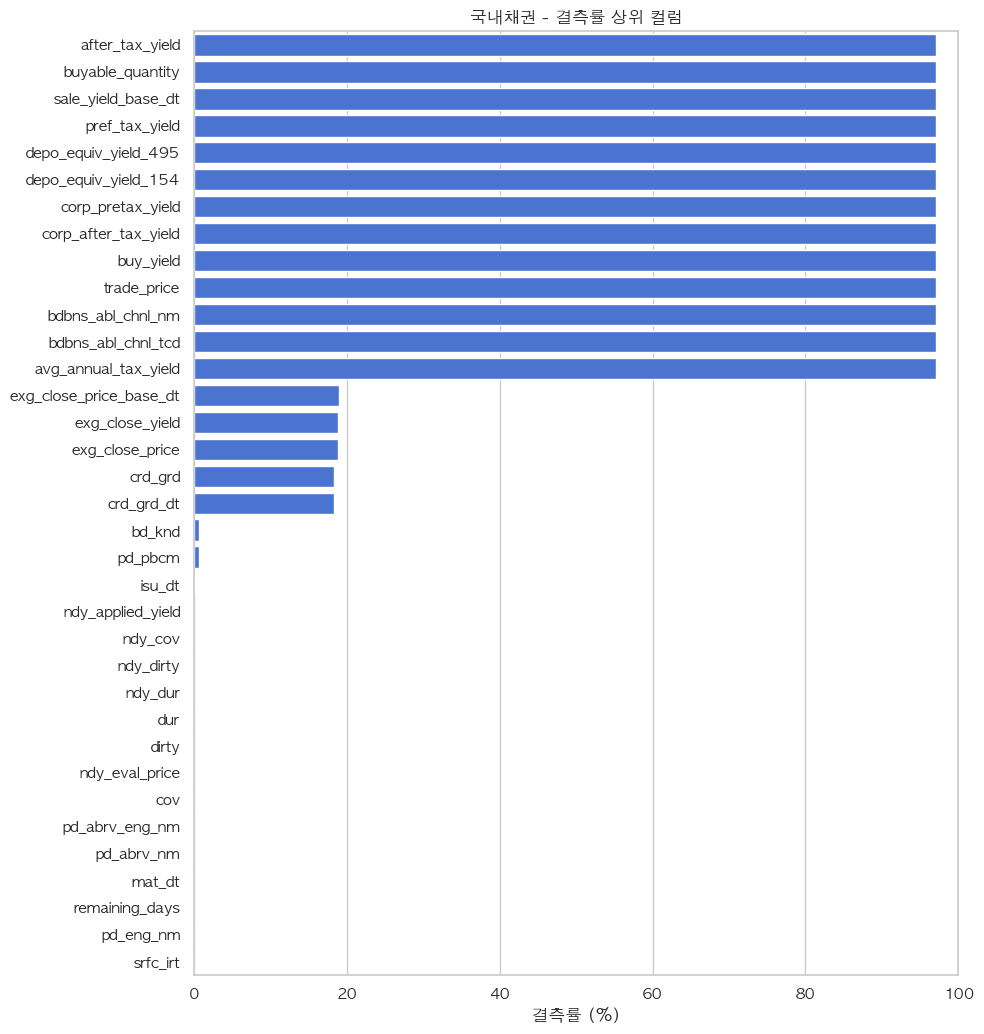

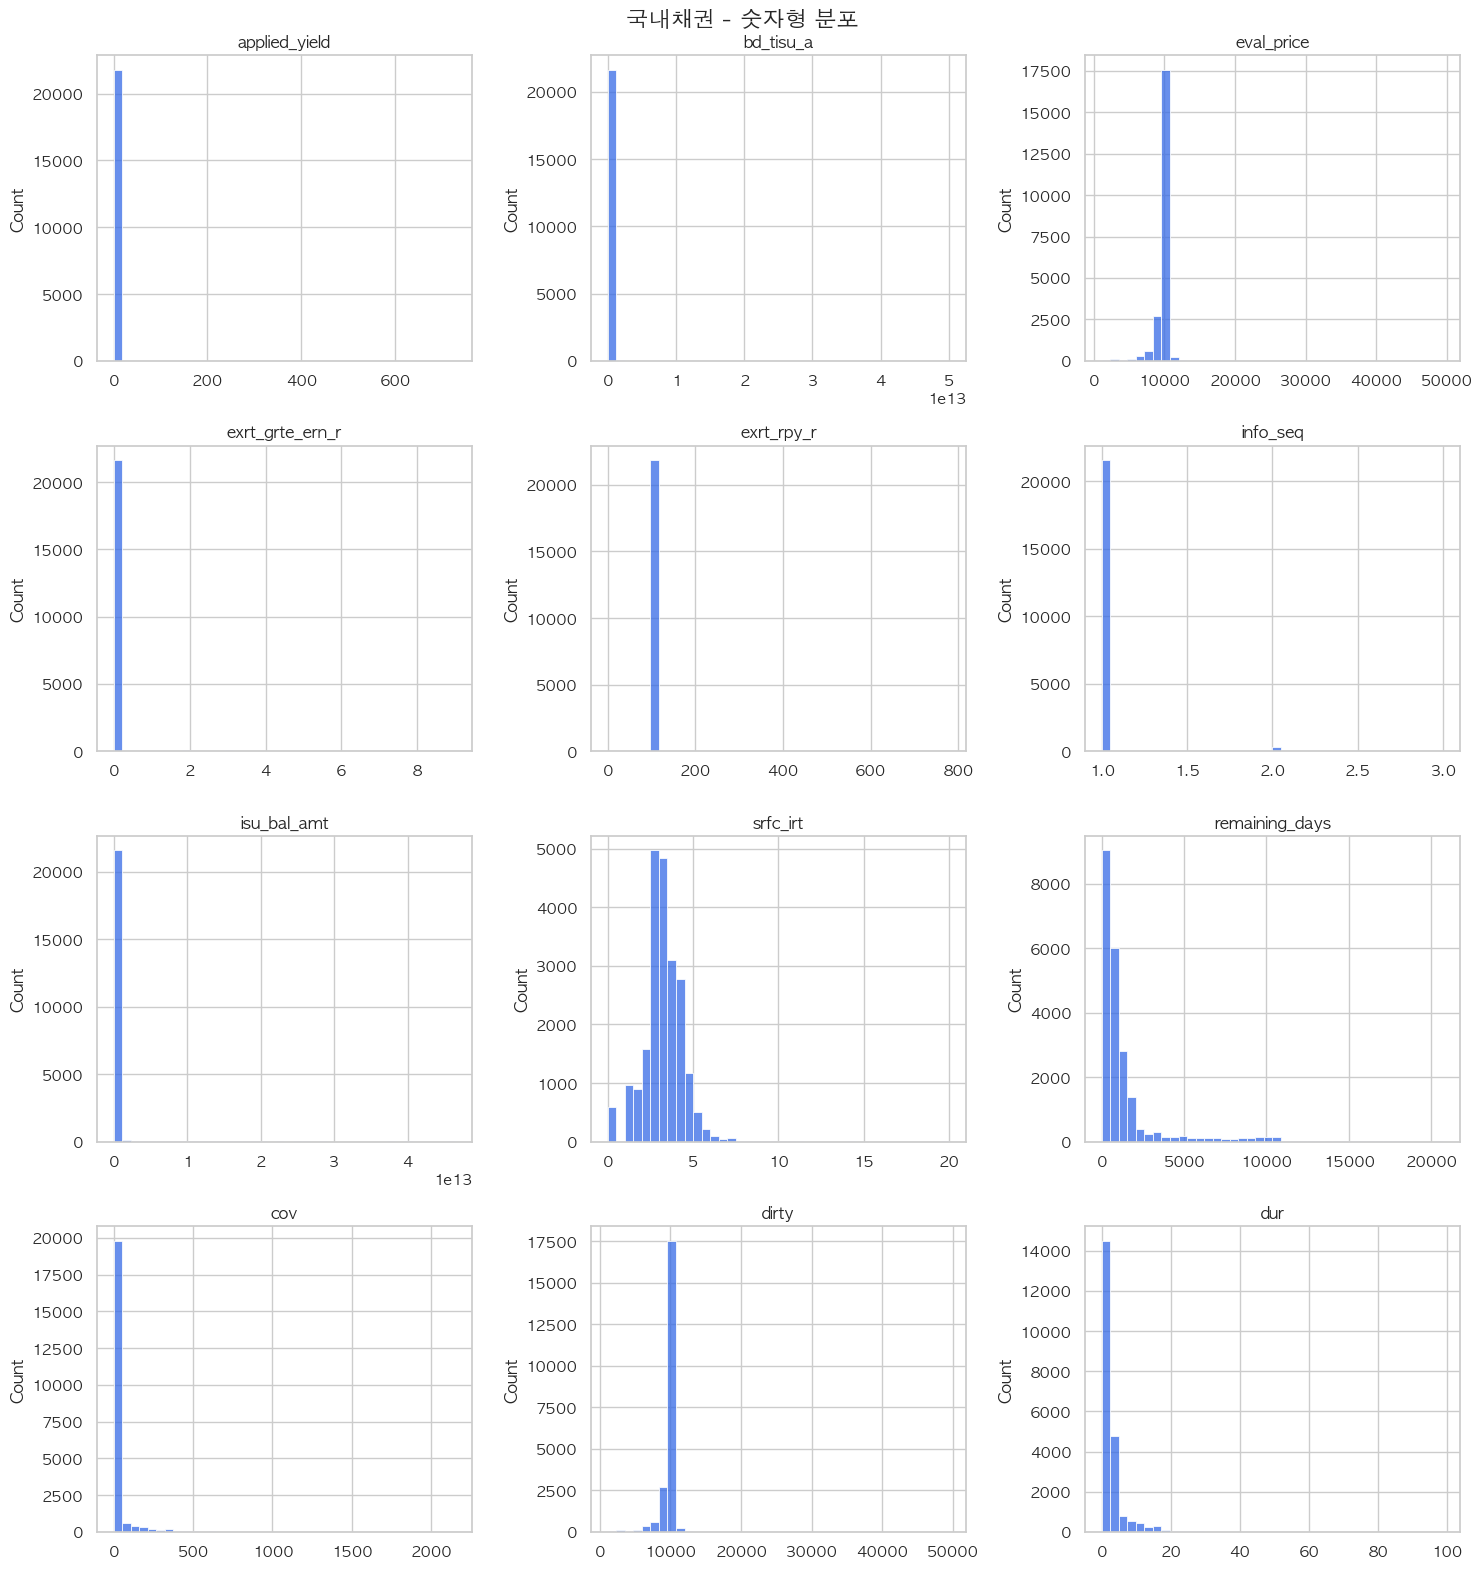

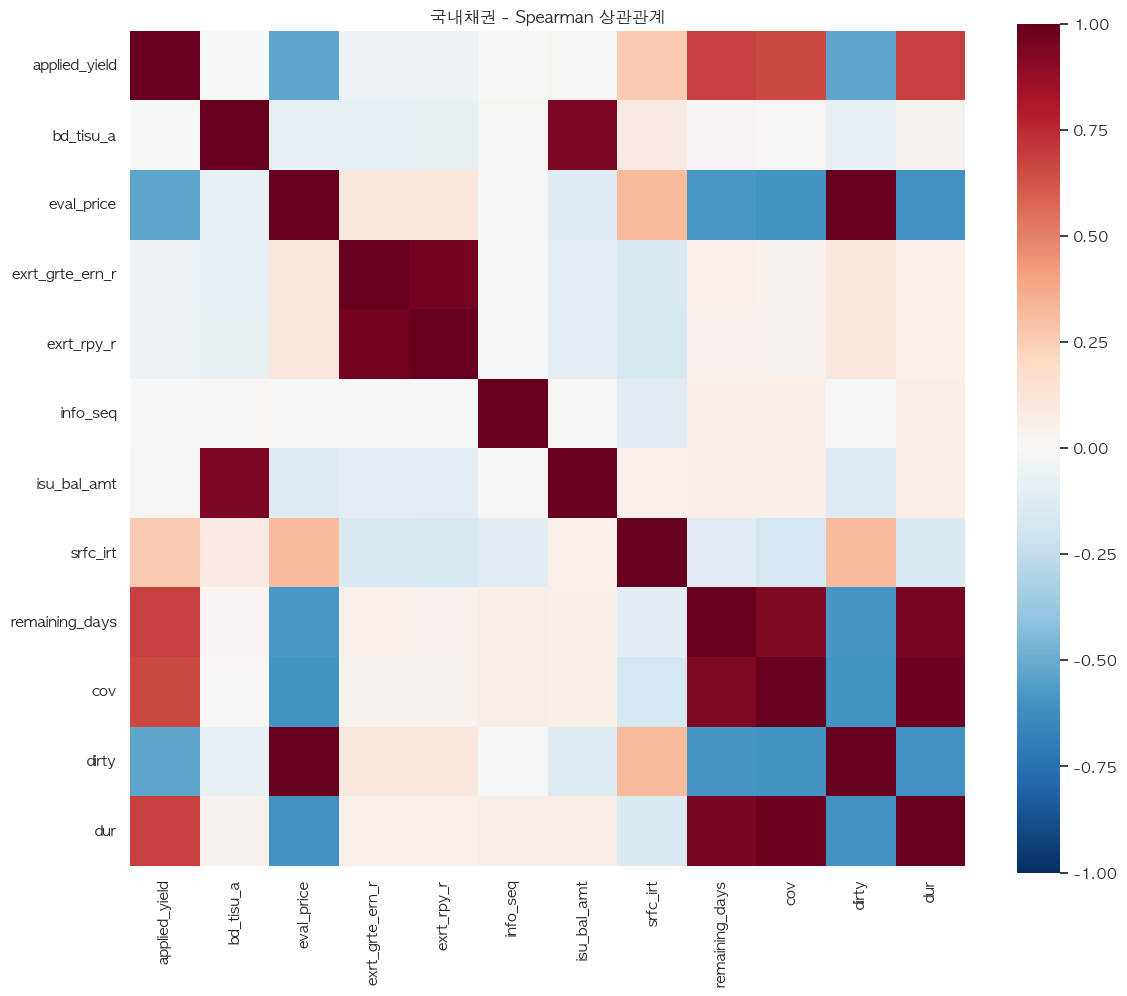

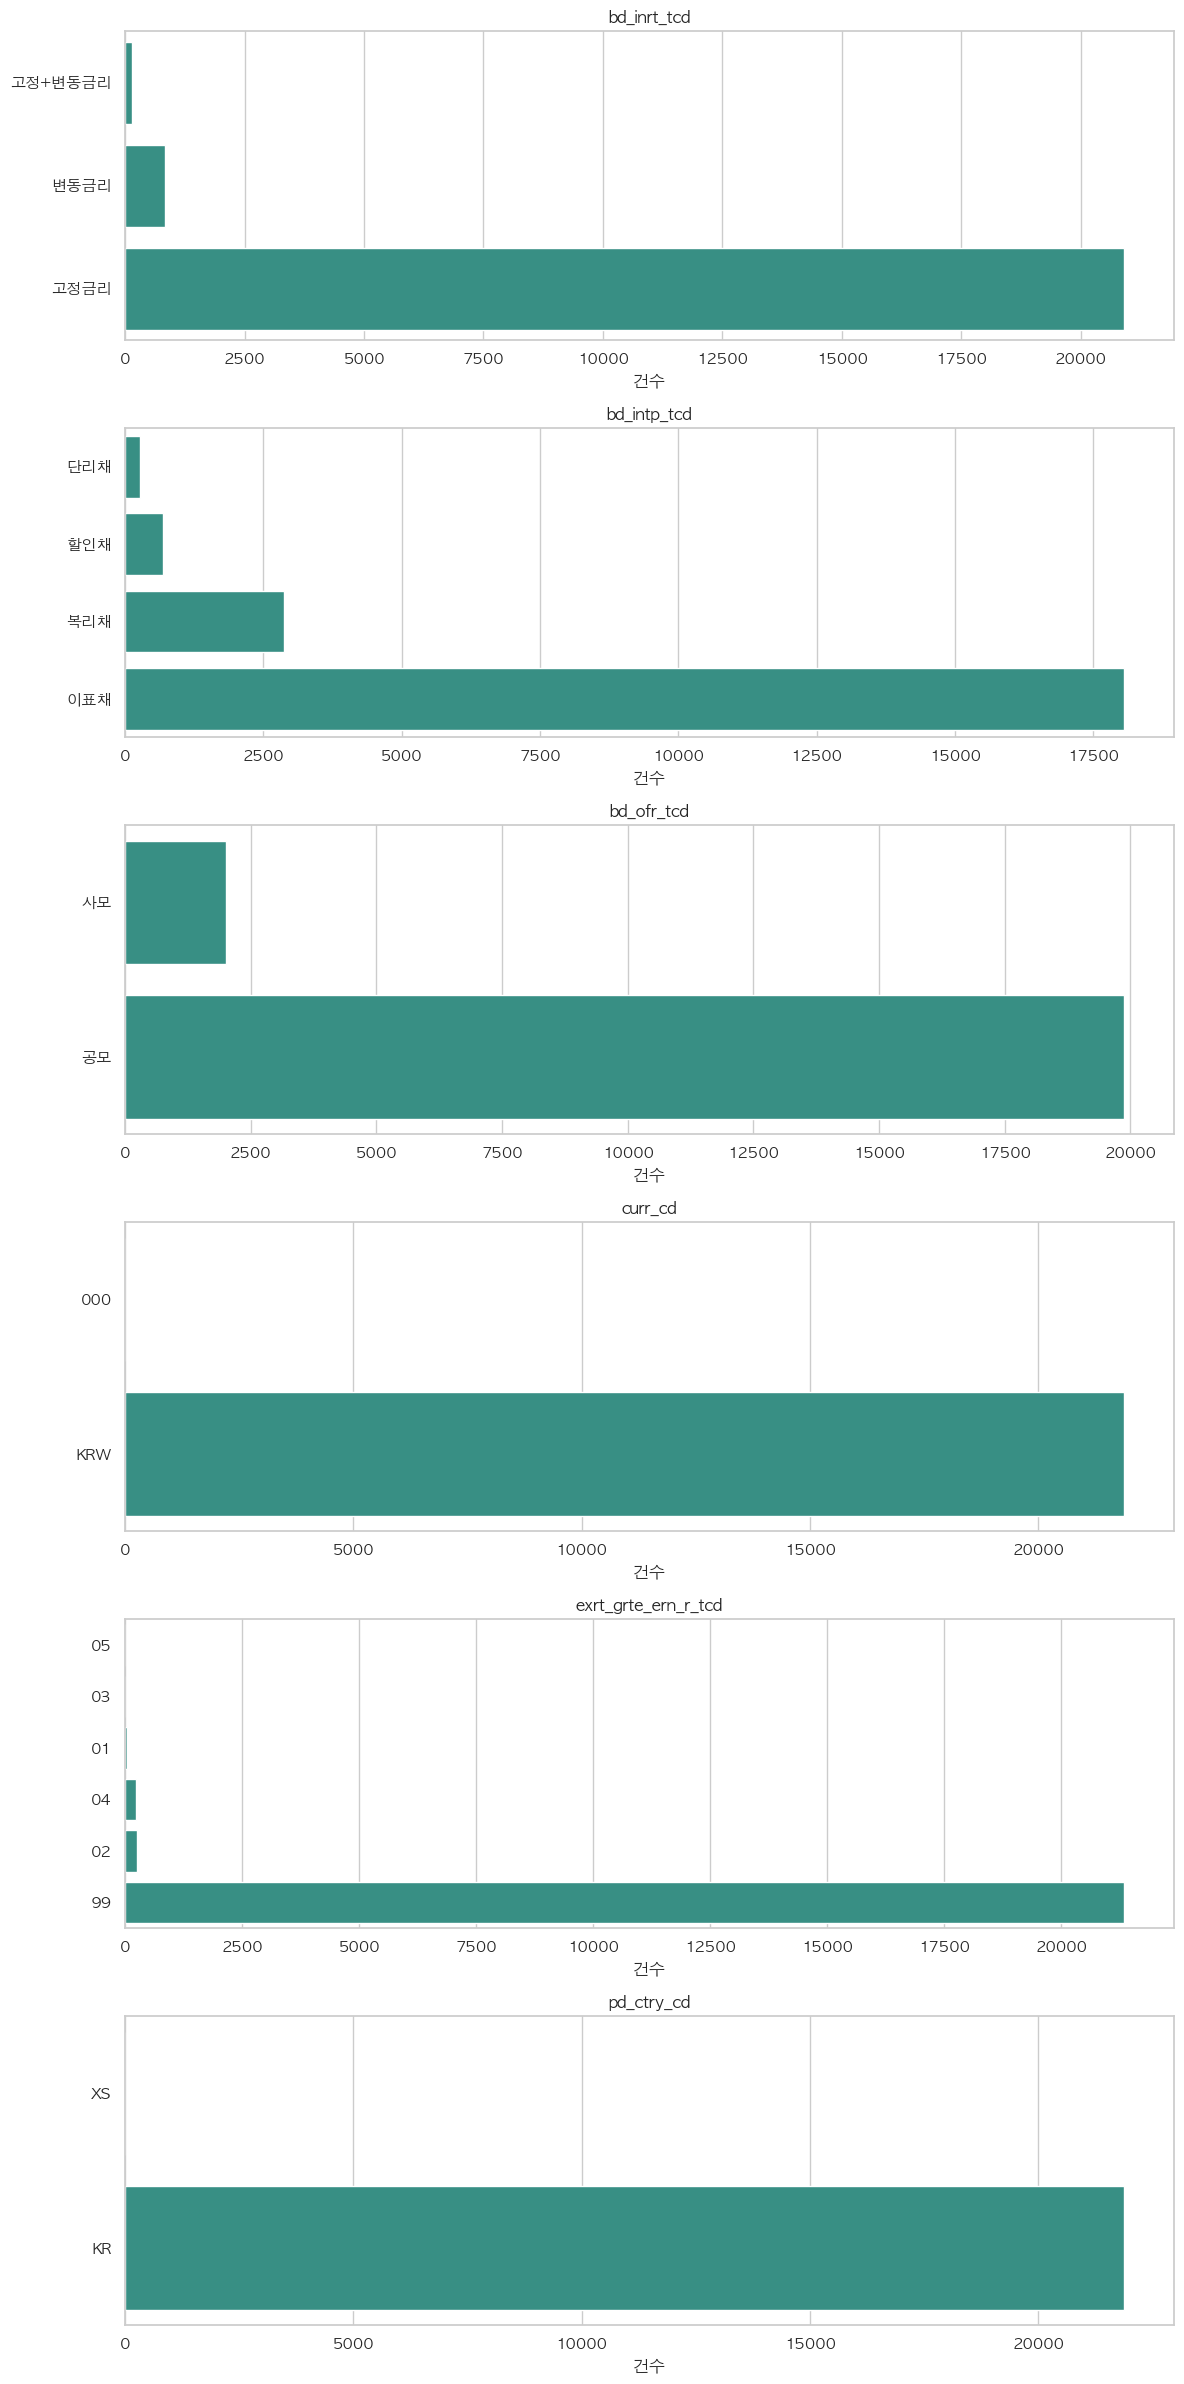

In [30]:
plot_product_eda(SELECTED_PRODUCT, df)

### 금융 지표 후보 요약

In [31]:
summary = finance_summary(df)
if summary.empty:
    print("자동 탐색된 금융 지표 후보가 없습니다.")
else:
    display(summary)

,count,mean,std,min,1%,25%,50%,75%,99%,max
eval_price,"21,882.0000","9,740.1075","1,222.9856","1,112.0600","4,987.0509","9,736.3200","9,961.2350","10,046.0350","11,143.8142","49,493.5300"
applied_yield,"21,882.0000",4.8944,16.4926,0.0000,0.2169,3.7230,4.0920,4.4190,7.3635,728.5240
exrt_grte_ern_r,"21,882.0000",0.0357,0.3803,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,9.0000
srfc_irt,"21,881.0000",3.1953,1.1950,0.0000,0.0000,2.5700,3.1700,3.9120,6.1000,20.0000
ndy_cov,"21,866.0000",27.8461,100.5747,0.0000,0.0008,0.7273,3.2110,11.4187,395.3293,"2,151.4550"
ndy_eval_price,"21,866.0000","9,733.2965","1,251.3196",0.0000,"4,713.4900","9,736.2550","9,961.3000","10,046.0975","11,145.2635","49,497.3200"
cov,"21,866.0000",27.3057,98.7408,0.0000,0.0013,0.7269,3.2093,11.3354,393.7542,"2,151.4139"
ndy_dur,"21,866.0000",2.8278,4.1192,0.0000,0.0152,0.7110,1.6374,3.1973,17.7523,99.0000
ndy_dirty,"21,866.0000","9,733.7425","1,251.3468",0.0000,"4,713.4900","9,736.5825","9,961.8200","10,047.0150","11,145.2635","49,497.3200"
dirty,"21,866.0000","9,740.4443","1,223.3721","1,112.0600","4,986.9085","9,736.6475","9,961.4800","10,046.5900","11,144.0030","49,493.5300"


## 4. 공모펀드 (`prfd01n001`)

In [32]:
SELECTED_PRODUCT = "prfd01n001"
df = datasets[SELECTED_PRODUCT]

print(f"상품군: {PRODUCTS[SELECTED_PRODUCT]} ({SELECTED_PRODUCT})")
print(f"형태: {df.shape[0]:,}행 × {df.shape[1]:,}열")
display(quality_flags(df))
display(df.head())

상품군: 공모펀드 (prfd01n001)
형태: 23,676행 × 75열


,항목,개수
0,전체 결측 컬럼,1
1,결측률 90% 이상 컬럼,2
2,단일값 컬럼(결측 제외),2


,bmrk_eng_nm,bmrk_nm,bns_bpr,curr_cd,exchdg_yn,fd_daily_bas_dt,fd_estb_ctry_cd,fd_ivst_rgn_desc,fd_last_dstb_actg_bss_dt,fd_last_dstb_actg_eot_dt,fd_last_dstb_r,fd_mm18_ern_r,fd_mm1_ern_r,fd_mm3_ern_r,fd_mm6_ern_r,fd_nast_suma,fd_price_bas_dt,fd_prsv_r,fd_sbpr,fd_set_pcd,fd_wk1_ern_r,fd_yr1_ern_r,fd_yr2_ern_r,fd_yr3_ern_r,fd_yr5_ern_r,frc_bpr_itm_yn,fss_itm_no,han_clas_fee_type,han_clas_nm,han_clas_policies,han_clas_sales_channel,hdge_fd_yn,int_dvd_desc,itm_abrv_nm,itm_eabrv_nm,itm_eng_nm,itm_nm,itm_no,kofia_fd_ccd,ksd_itm_no,mtco_itm_no,ofsfd_yn,ofwk_trus_rwrd_r,or_attr_desc,or_co_rwrd_r,or_co_xtn_itt_cd,ovrs_fd_desc,pers_corp_desc,pfiv_sale_cntl_tcd,prfd_attr_cds,prfd_attr_cnt,prfd_attr_search_text,prvo_fd_desc,prvo_pbff_desc,rptt_ksd_itm_no,sale_co_rwrd_r,sale_yn,std_itm_no,thco_sale_yn,trusc_rwrd_r,trusc_xtn_itt_cd,zrin_attr_nms,zrin_btyp_cd,zrin_btyp_nm,zrin_dmst_bd_cmst_rt,zrin_dmst_stk_cmst_rt,zrin_etc_ast_cmst_rt,zrin_fd_cmst_rt,zrin_fd_ivst_risk_gcd,zrin_fd_ivst_risk_grd_nm,zrin_liqt_cmst_rt,zrin_ovrs_bd_cmst_rt,zrin_ovrs_stk_cmst_rt,zrin_pcd,zrin_ptn_nm
0,<NA>,<NA>,NaN,KRW,<NA>,NaT,000,국내,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2.0250,0,00,NaN,NaN,NaN,NaN,NaN,0,000000000000,<NA>,<NA>,<NA>,<NA>,0,배당,CRYSTAL신MMFE1-1비주,<NA>,크리스탈신종MMFE1-1비주식,크리스탈신종MMFE1-1비주식,KR5010101611,00000000000000000000,KRZ500023970,31147,0,0.0000,MMF,2.0000,00040011,국내,해당없음,00,<NA>,0,<NA>,해당없음,공모,KR0000000000,2.0250,판매완료,KR5205363884,<NA>,0.3500,00020081,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,<NA>,<NA>
1,채권종합지수 1~2Y,채권종합지수 1~2년,NaN,KRW,<NA>,NaT,000,국내,2011-09-07,2011-09-19,-0.0880,NaN,NaN,NaN,NaN,NaN,NaT,0.0000,0,00,NaN,NaN,NaN,NaN,NaN,0,000000000000,<NA>,<NA>,<NA>,<NA>,0,배당,스페셜단기43호,<NA>,스페셜단기43호,스페셜단기43호,KR5010151053,00000000000000000000,KRZ500024060,31193,0,0.0000,채권형,2.0000,00040011,국내,해당없음,00,"C101,V101,D102,C103",4,D102 국내위탁판매 V101 국내 C101 추가 C103 개방,해당없음,공모,KR0000000000,8.0000,판매완료,KR5205103363,<NA>,0.5000,00020081,"추가,국내,개방,국내위탁판매",29,기타,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,29920,영구미분류
2,<NA>,<NA>,NaN,KRW,<NA>,NaT,000,해당없음,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,10.0000,0,00,NaN,NaN,NaN,NaN,NaN,0,000000000000,<NA>,<NA>,<NA>,<NA>,0,이자,D프로단기1,<NA>,서울D프로단기1,서울D프로단기1,KR5010151901,00000000000000000000,,76623,0,0.0000,채권혼합,2.5000,00040011,국내,해당없음,00,<NA>,0,<NA>,해당없음,공모,KR0000000000,10.0000,판매완료,,<NA>,0.5000,00020081,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,<NA>,<NA>
3,채권종합지수 1~2Y,채권종합지수 1~2년,NaN,KRW,<NA>,NaT,000,국내,2010-11-03,2011-10-30,48.5650,NaN,NaN,NaN,NaN,NaN,NaT,8.0000,0,00,NaN,NaN,NaN,NaN,NaN,0,000000000000,<NA>,<NA>,<NA>,<NA>,0,배당,스페셜중기41호,<NA>,스페셜중기41호,스페셜중기41호,KR5010201043,00000000000000000000,KRZ500022730,11341,0,0.0000,채권형,2.0000,00040011,국내,해당없음,00,"C103,D102,V101,C101",4,C101 추가 V101 국내 D102 국내위탁판매 C103 개방,해당없음,공모,KR0000000000,8.0000,판매완료,KR5205102944,<NA>,0.5000,00020081,"국내,추가,국내위탁판매,개방",29,기타,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,29920,영구미분류
4,채권종합지수 1~2Y,채권종합지수 1~2년,NaN,KRW,<NA>,NaT,000,국내,2011-10-22,2012-07-11,0.6730,NaN,NaN,NaN,NaN,NaN,NaT,0.0000,0,00,NaN,NaN,NaN,NaN,NaN,0,000000000000,<NA>,<NA>,<NA>,<NA>,0,배당,D스페셜중기S20호,<NA>,D스페셜중기주식20,D스페셜중기주식20,KR5010201933,00000000000000000000,KRZ500025030,46605,0,0.0000,채권혼합,2.0000,00040011,국내,해당없음,00,"V101,C101,C103,D102",4,D102 국내위탁판매 C103 개방 V101 국내 C101 추가,해당없음,공모,030410046605,8.0000,판매완료,KR5205204807,<NA>,0.5000,00020081,"국내,추가,개방,국내위탁판매",29,기타,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,29920,영구미분류


### 컬럼 프로파일과 스키마 설명

In [33]:
profile_columns = [
    "column", "description", "schema_type", "pandas_dtype", "nullable",
    "missing_count", "missing_pct", "unique_count",
    "mean", "median", "min", "max", "sample_values",
]
profile_columns = [
    column for column in profile_columns
    if column in profiles[SELECTED_PRODUCT].columns
]

profile_view = (
    profiles[SELECTED_PRODUCT][profile_columns]
    .sort_values(["missing_pct", "unique_count"], ascending=[False, False])
    .reset_index(drop=True)
)
display(profile_view)

,column,description,schema_type,pandas_dtype,nullable,missing_count,missing_pct,unique_count,mean,median,min,max,sample_values
0,fd_wk1_ern_r,펀드 1주일수익률,"numeric(30,2)",float64,YES,23676,100.0000,0,NaN,NaN,NaN,NaN,
1,itm_eabrv_nm,종목영문약어명,text,string,YES,23528,99.3700,143,NaN,NaN,NaN,NaN,Fidel_Singapore | FidelityIndonesi | GRC
2,fd_yr5_ern_r,펀드 5년수익률,"numeric(30,2)",float64,YES,17697,74.7500,4882,53.2042,33.6100,-99.9500,"1,793.3900",14.51 | 48.35 | 48.92
3,han_clas_policies,클래스 부가 정책,text,string,YES,17408,73.5300,33,NaN,NaN,NaN,NaN,"랩,펀드 | 보수체감 | 개인연금"
4,fd_yr3_ern_r,펀드 3년수익률,"numeric(30,2)",float64,YES,17186,72.5900,5110,69.0426,45.3400,-99.4900,"2,193.7600",9.39 | 18.1 | 8.82
5,fd_yr2_ern_r,펀드 2년수익률,"numeric(30,2)",float64,YES,16919,71.4600,4952,51.8753,31.1500,-96.9000,"1,793.5800",5.6 | 12.81 | 6.15
6,fd_mm18_ern_r,펀드 18개월수익률,"numeric(30,2)",float64,YES,16789,70.9100,4645,46.3512,20.2700,-95.6700,"1,613.8200",3.92 | 2.39 | 4.76
7,exchdg_yn,환헤지여부,text,string,YES,16695,70.5100,2,NaN,NaN,NaN,NaN,N | Y
8,fd_yr1_ern_r,펀드 1년수익률,"numeric(30,2)",float64,YES,16654,70.3400,4469,33.3343,15.8400,-92.8200,"1,436.2400",2.57 | 3.2 | 1.7
9,fd_mm6_ern_r,펀드 6개월수익률,"numeric(30,2)",float64,YES,16456,69.5000,3163,4.9569,3.3950,-87.8000,58.7100,1.29 | -2.09 | -0.36


### 결측치·분포·상관관계·범주형 빈도

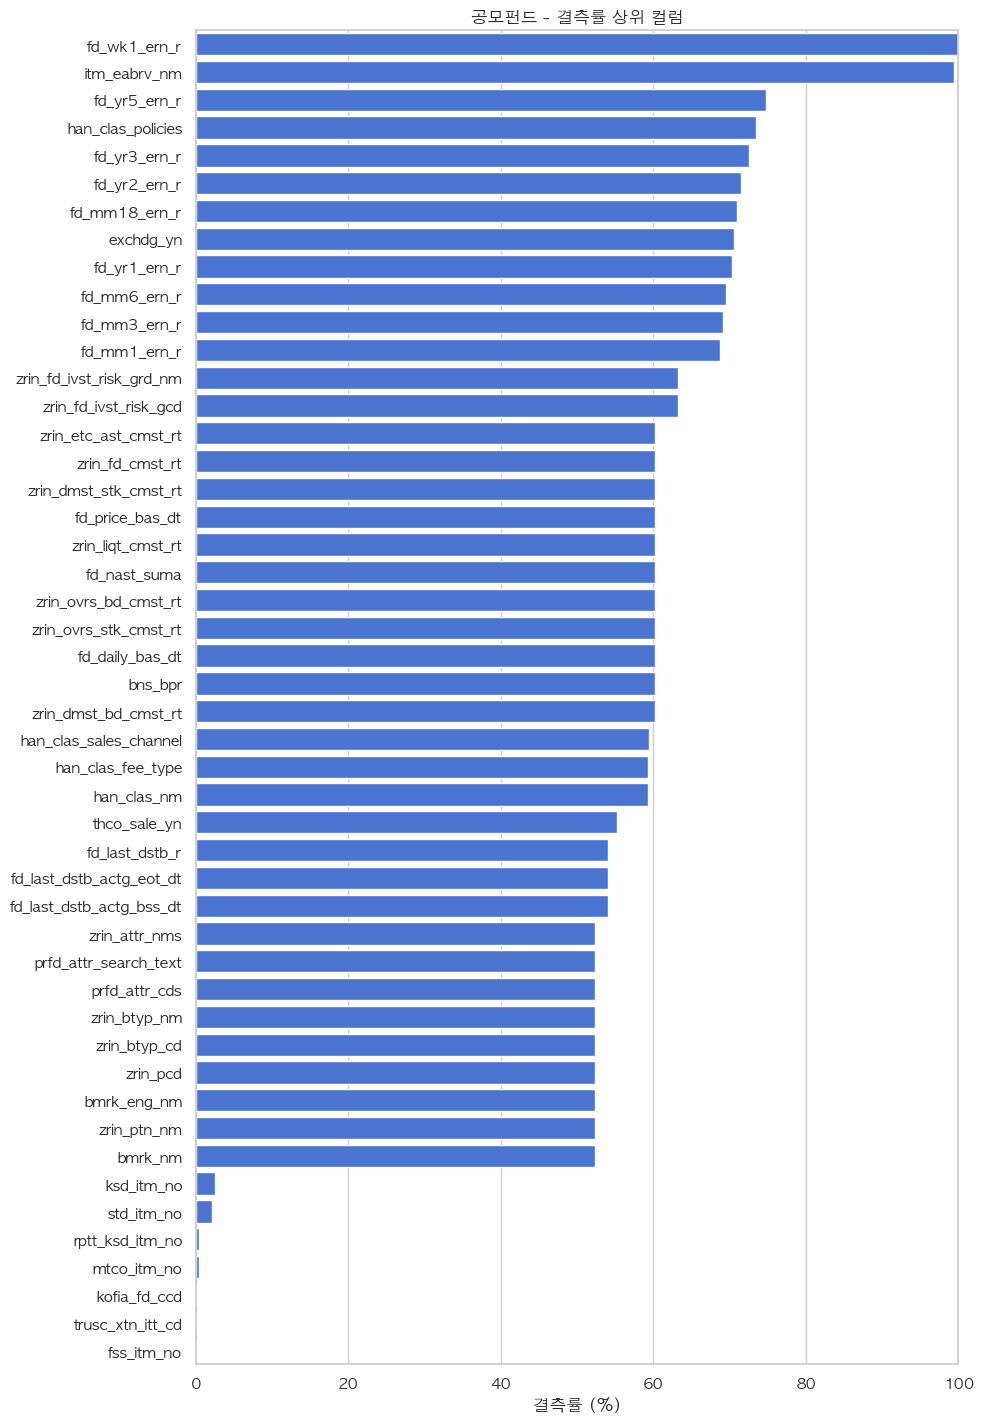

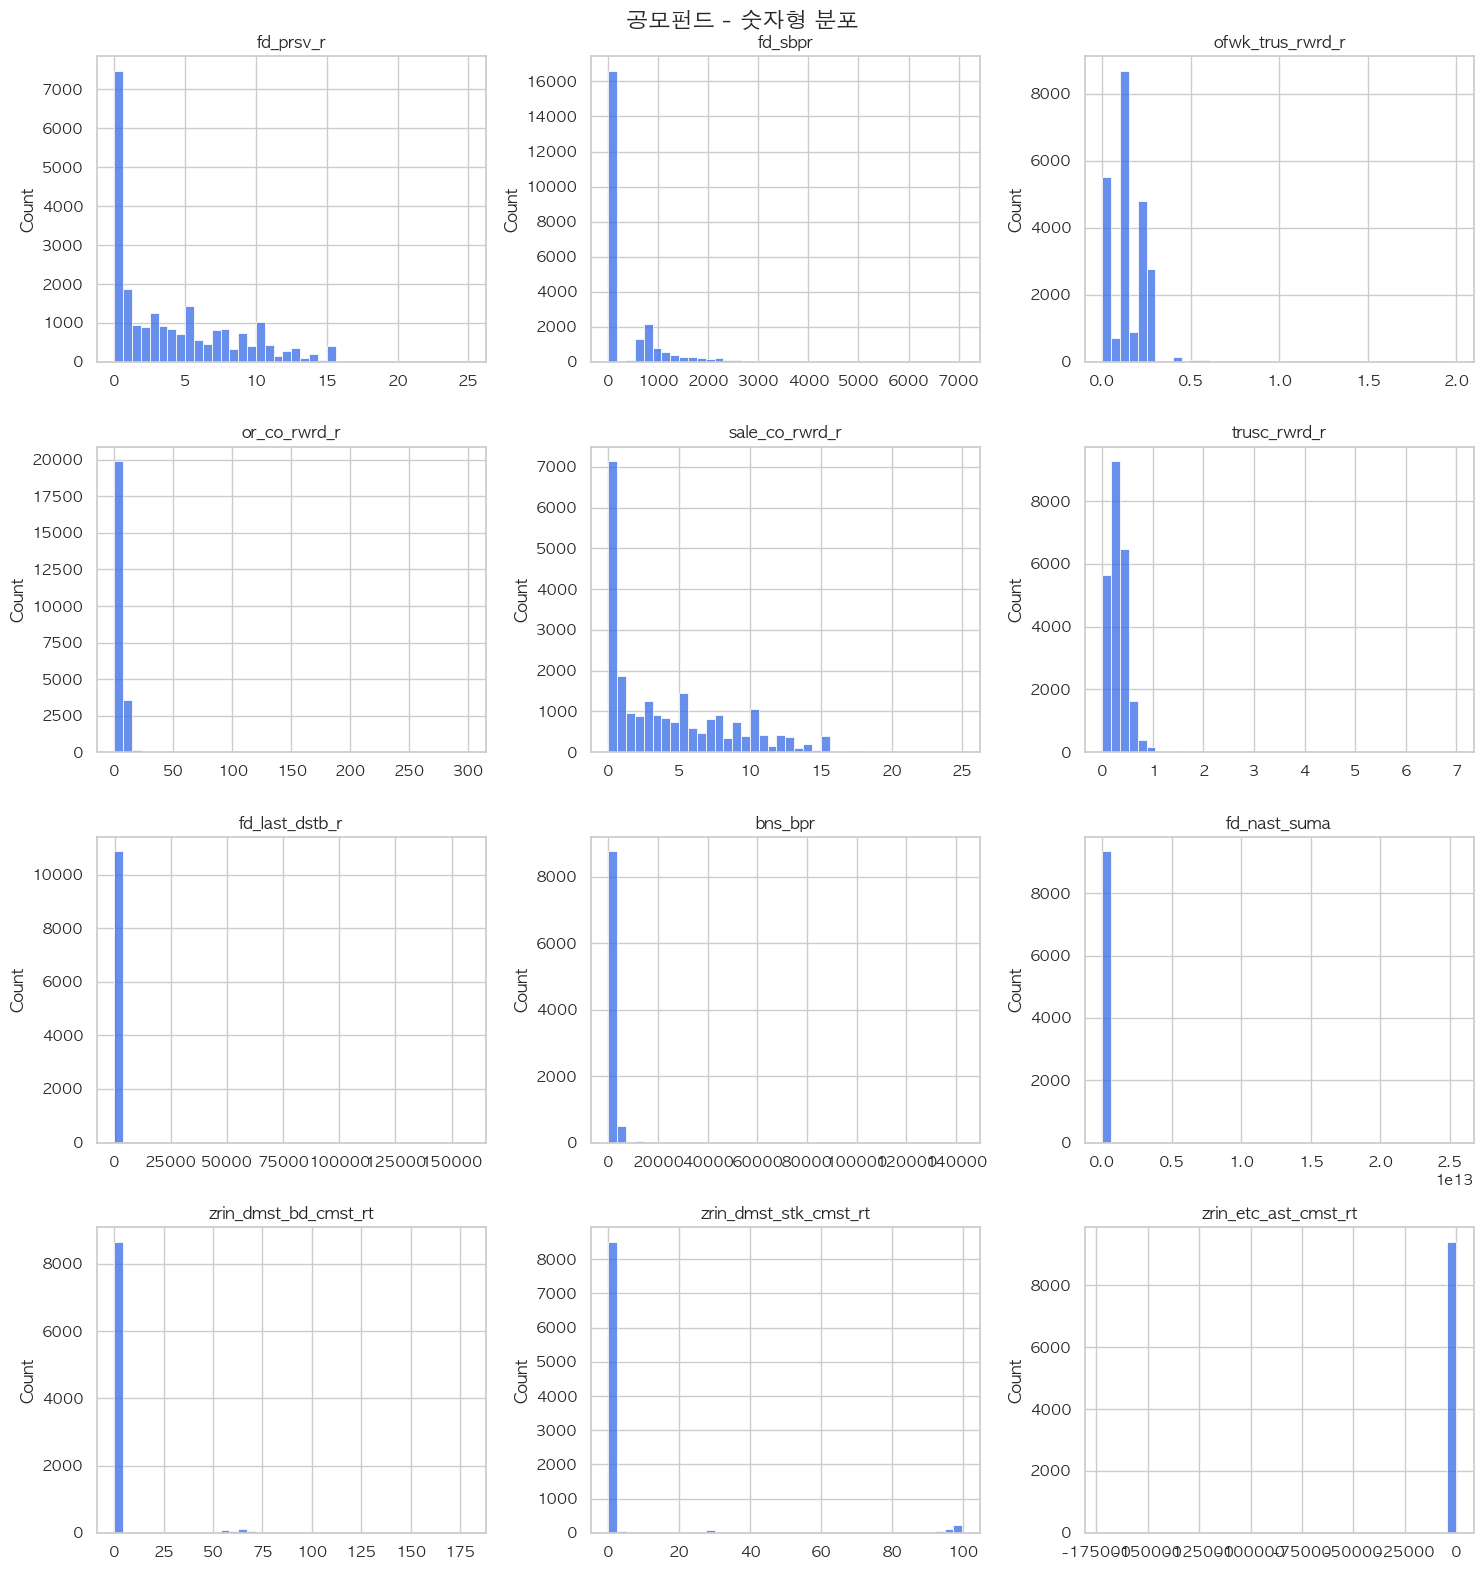

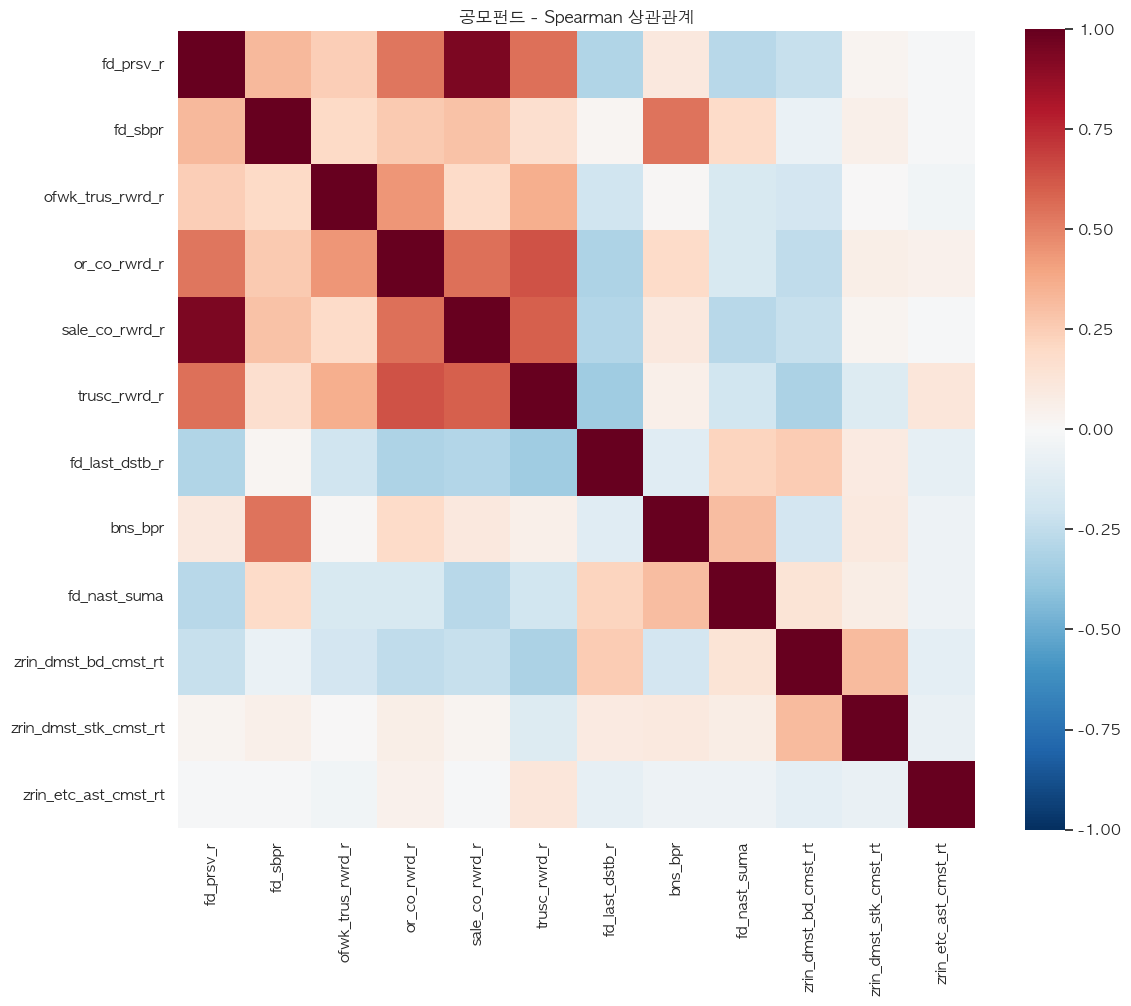

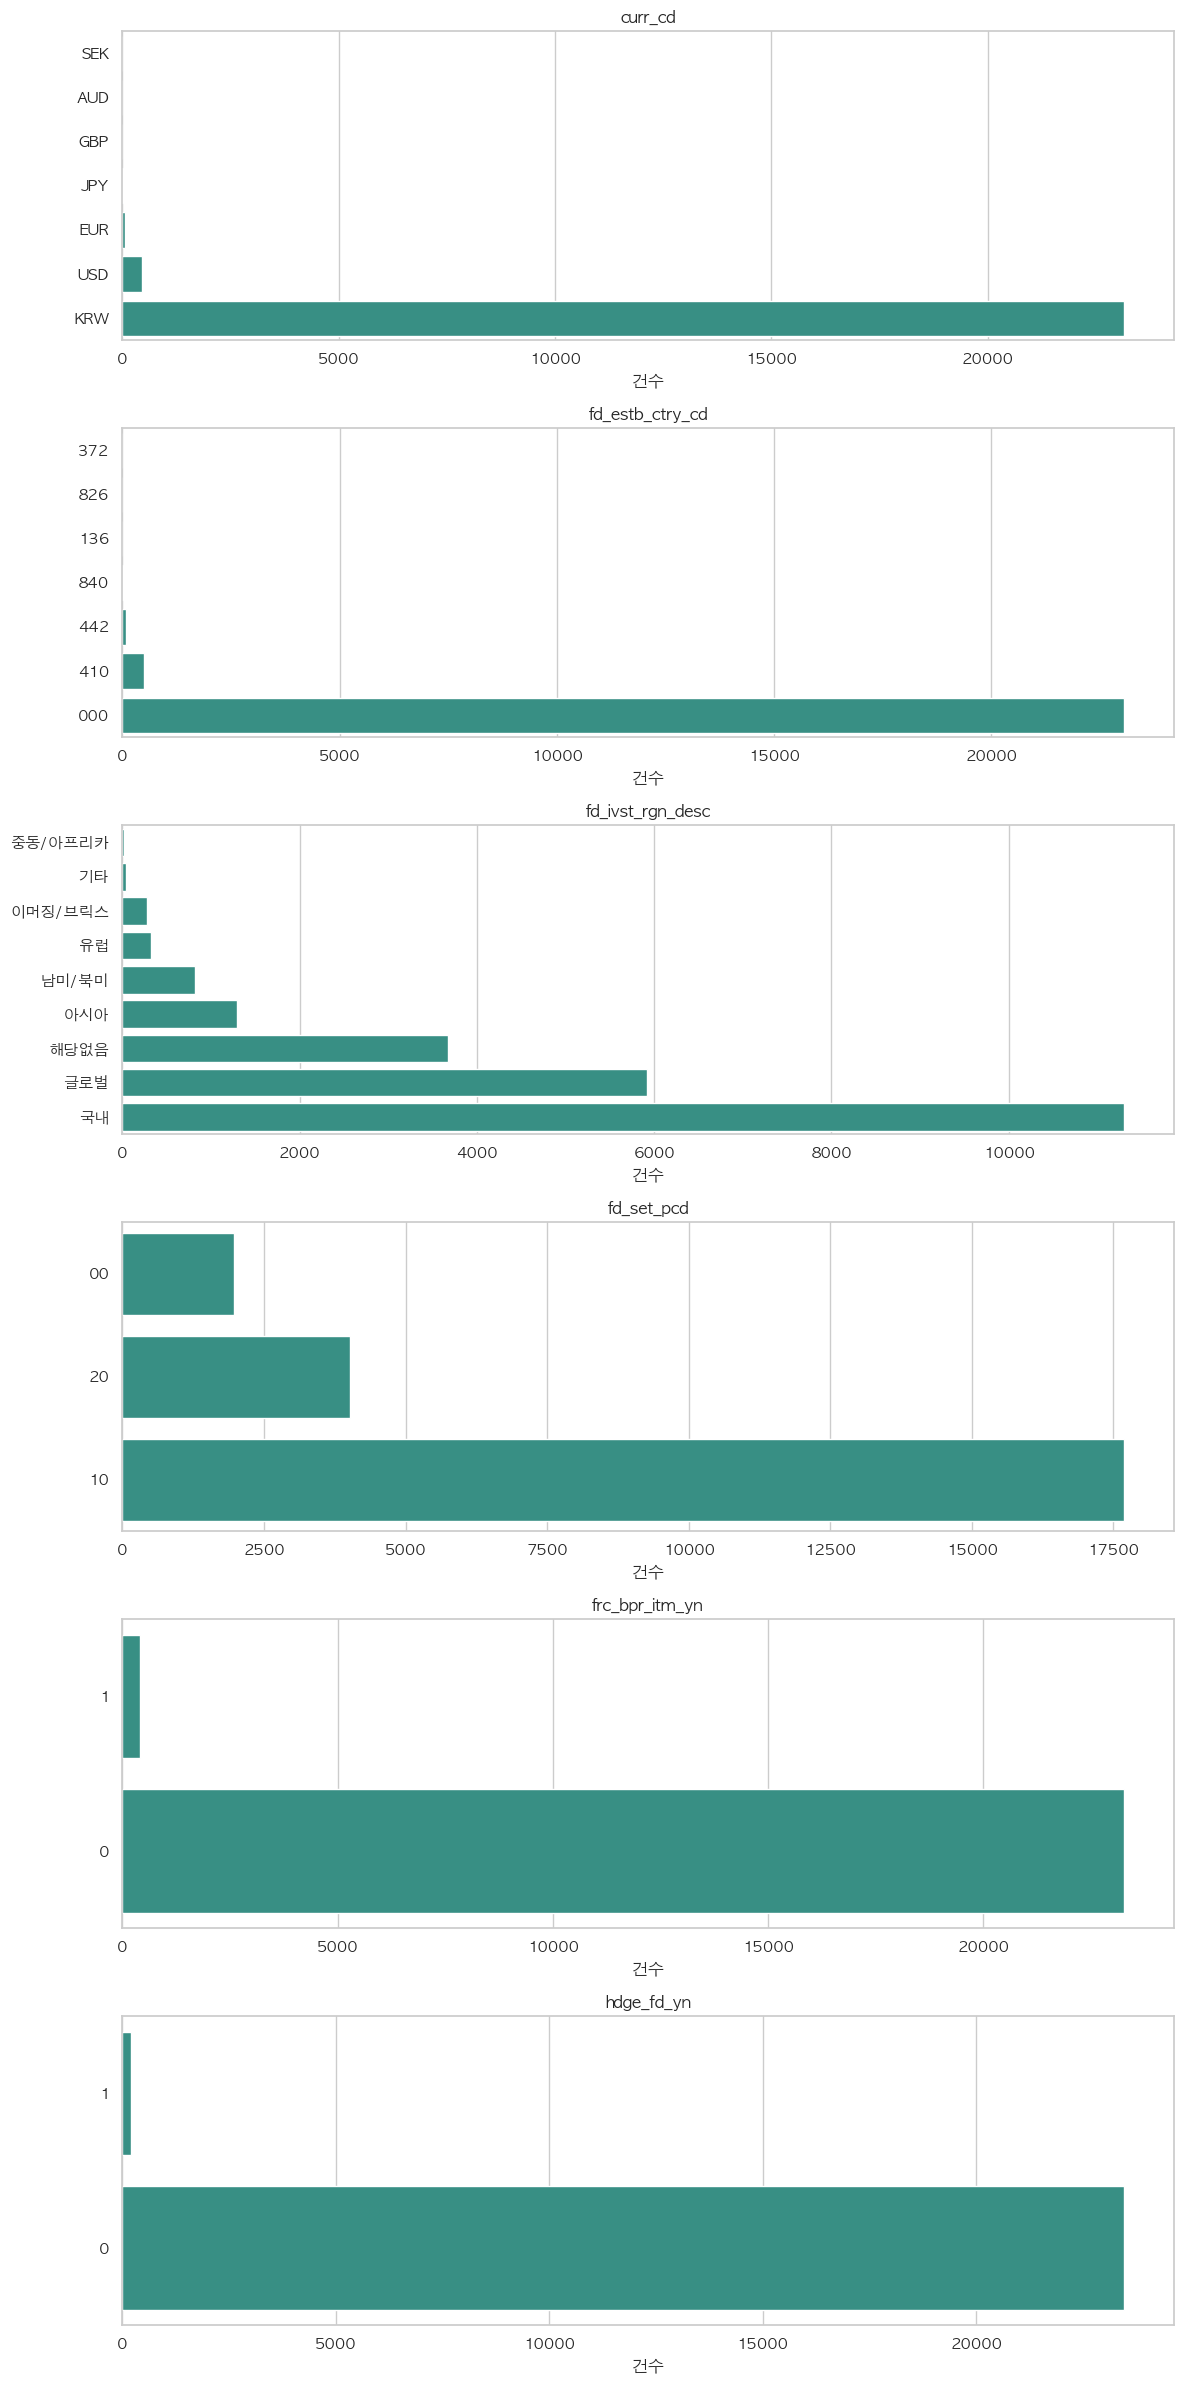

In [34]:
plot_product_eda(SELECTED_PRODUCT, df)

### 금융 지표 후보 요약

In [35]:
summary = finance_summary(df)
if summary.empty:
    print("자동 탐색된 금융 지표 후보가 없습니다.")
else:
    display(summary)

,count,mean,std,min,1%,25%,50%,75%,99%,max
ofwk_trus_rwrd_r,"23,676.0000",0.1349,0.1031,0.0000,0.0000,0.0600,0.1400,0.2000,0.4000,2.0000
or_co_rwrd_r,"23,676.0000",3.7089,3.7502,0.0000,0.0000,1.0000,2.8800,6.0000,11.9000,300.0000
fd_sbpr,"23,676.0000",348.8223,649.0237,0.0000,0.0000,0.0000,0.0000,700.0000,"2,838.2500","7,075.0000"
trusc_rwrd_r,"23,676.0000",0.3086,0.2056,0.0000,0.0000,0.2000,0.3000,0.4000,0.9000,7.0000
sale_co_rwrd_r,"23,676.0000",4.2507,4.2864,0.0000,0.0000,0.4000,3.0000,7.0000,15.0000,25.0000
zrin_ovrs_bd_cmst_rt,"9,413.0000",0.3594,5.7564,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,99.9800
zrin_liqt_cmst_rt,"9,413.0000",41.8365,"2,509.9129",0.0000,0.0000,0.3200,1.3100,3.5700,79.8200,"172,200.2600"
zrin_fd_cmst_rt,"9,413.0000",73.2674,41.1397,0.0000,0.0000,56.4800,96.1500,99.3100,101.7468,193.9600
zrin_etc_ast_cmst_rt,"9,413.0000",-28.7468,"2,508.7730","-172,100.2600",-49.3700,0.0000,0.0000,3.4000,100.0000,100.0000
zrin_dmst_stk_cmst_rt,"9,413.0000",6.2959,22.3140,0.0000,0.0000,0.0000,0.0000,0.0000,98.9300,99.9200


## 4. 국내 ETF (`pref01n001`)

In [36]:
SELECTED_PRODUCT = "pref01n001"
df = datasets[SELECTED_PRODUCT]

print(f"상품군: {PRODUCTS[SELECTED_PRODUCT]} ({SELECTED_PRODUCT})")
print(f"형태: {df.shape[0]:,}행 × {df.shape[1]:,}열")
display(quality_flags(df))
display(df.head())

상품군: 국내 ETF (pref01n001)
형태: 1,780행 × 98열


,항목,개수
0,전체 결측 컬럼,4
1,결측률 90% 이상 컬럼,5
2,단일값 컬럼(결측 제외),14


,cu_base_index,cu_charge_etc_rt,cu_charge_rt,cu_fund_mgmt_co,cu_lev_fector,cu_strtegy,cu_upt_dt,du_bpr,du_chas_errt,du_chas_errt_base_dt,du_clpr,du_diff_rt,du_diff_rt_base_dt,du_er_1d,du_er_1m,du_er_1y,du_er_3m,du_er_6m,du_er_ytd,du_hpr,du_last_aum,du_last_nav,du_lpr,du_nav_base_dt,du_nav_rnf_amt,du_nav_yday,du_upt_dt,du_val_1d,du_val_1m,du_val_5d,du_vlty_1m,du_vlty_1y,du_vlty_3m,du_vlty_6m,du_vlty_base_dt,du_vol_1d,du_vol_avg_1m,du_vol_avg_5d,fn_average_coupon,fn_average_maturity,fn_average_quality,fn_base_dt,fn_effective_duration,fn_effective_maturity,fn_modified_duration,fn_nominal_maturity,fn_portfolio_dt,pd_abrv_nm,pd_circ_net_tamt,pd_circ_stk_cnt,pd_curr_cd,pd_curr_nm,pd_divd_amt_ann,pd_divd_amt_pshr,pd_dvid_base_dt,pd_dvid_cycl,pd_dvid_inc_dist,pd_dvid_nav,pd_dvid_pay_cnt,pd_dvid_pay_months,pd_dvid_prc_base_dt,pd_dvid_tax_basis,pd_dvid_yield,pd_exg_mkt_cd,pd_exg_mkt_nm,pd_grp_no,pd_isin_cd,pd_itm_no,pd_itm_no_ma,pd_lst_stk_cnt,pd_lste_dt,pd_lstg_dt,pd_mkt_id,pd_mkt_nm,pd_net_tamt,pd_nm,pd_pen_risk_nm,pd_pen_tr_yn,pd_ric,pd_risk_cd,pd_risk_nm,pd_sale_yn,pd_sect_cd,pd_spac_yn,pd_stk_cnt,pd_ticker,pd_tr_yn,ref_ast_type,ref_base_dt,ref_base_index,ref_fund_mgmt_co,ref_geo_focus,ru_mkt_price,ru_mkt_volume,wu_core_yn,wu_inv_ast_type,wu_inv_rgn,wu_upt_dt
0,,<NA>,<NA>,KB,1,액티브,2026-08-24,"9,800.0000",35.1400,2026-08-21,"9,050.0000",-0.1100,2026-08-21,-7.6500,8.5100,-20.2300,-27.9500,-44.3200,-41.1600,"9,470.0000","53,907,833,000.0000","9,060.1400","8,915.0000",2026-08-21,-690.3800,"9,750.5200",2026-08-21,"3,155,290,152.0000","2,992,916,177.9500","2,671,795,446.0000",93.3974,46.3337,60.2041,54.0252,2026-08-21,"346,324.0000","327,080.0500","280,918.6000",NaN,NaN,<NA>,2026-08-22,NaN,NaN,NaN,NaN,2026-05-31,RISE 바이오TOP10액티브,"58,310,000,000.0000","5,950,000.0000",CURR_CD_KRW,한국원화,NaN,95.6077,2026-08-22,Q,NaN,"9,369.6300",4.0000,"January,April,July,October",2026-08-20,Gross,0.0408,EXG_MKT_NO_001,유가증권,ETF,KR70000Z0003,KR70000Z0003,A0000Z0,5850000,NaT,2024-12-24,STK,유가증권 ...,"57,040,533,390.0000",KB RISE 바이오TOP10액티브증권상장지수투자신탁(주식),위험자산,Y,0000Z0.KS,PD_RISK_GCD_12,높은위험(2등급),1,2,N,"5,850,000.0000",0000Z0,0,Equity,2026-08-22,KRX Bio TOP 10 KRW,KB Asset Ltd,Korea,"9,050.0000","346,324.0000",N,주식,국내,2026-08-21
1,,<NA>,<NA>,KB,1,합성복제,2026-08-24,"11,410.0000",0.3400,2026-08-21,"11,250.0000",0.2800,2026-08-21,-1.4000,-1.1900,4.1200,-5.2600,1.9000,2.6500,"11,500.0000","7,292,135,500.0000","11,218.6700","11,180.0000",2026-08-21,-187.1100,"11,405.7800",2026-08-21,"10,196,137.0000","15,338,977.5000","10,577,075.4000",22.4204,14.4162,17.4952,15.7402,2026-08-21,909.0000,"1,341.6500",925.6000,NaN,NaN,<NA>,2026-08-22,NaN,NaN,NaN,NaN,2025-07-31,RISE 미국S&P500엔화노출(합성 H),"7,416,500,000.0000","650,000.0000",CURR_CD_KRW,한국원화,"19,532.2972","4,883.0743",2026-08-22,Q,NaN,"11,370.5900",4.0000,"January,April,July,October",2026-08-20,Gross,1.7178,EXG_MKT_NO_001,유가증권,ETF,KR70005C0005,KR70005C0005,A0005C0,650000,NaT,2025-01-14,STK,유가증권 ...,"7,413,758,805.0000",KB RISE 미국S&P500엔화노출증권상장지수투자신탁(주식-파생형)(합성 H),N,N,0005C0.KS,PD_RISK_GCD_12,높은위험(2등급),1,2,N,"650,000.0000",0005C0,0,Equity,2026-08-22,S&P 500 Daily JPY Hedged CR,KB Asset Ltd,United States of America,"11,250.0000",909.0000,Y,주식,미국,2026-08-21
2,,<NA>,<NA>,삼성,1,액티브,2026-08-24,"10,175.0000",0.2500,2026-08-21,"10,185.0000",0.0600,2026-08-21,0.1000,0.5900,-0.7800,0.5400,0.7900,0.7400,"10,185.0000","554,345,617,000.0000","10,178.9500","10,175.0000",2026-08-21,0.6300,"10,178.3200",2026-08-21,"559,133,505.0000","276,639,215.9000","421,935,827.6000",1.9374,2.1928,1.2496,1.5894,2026-08-21,"54,905.0000","27,201.8500","41,441.6000",3.2404,NaN,<NA>,2026-08-22,NaN,1.3887,NaN,1.3887,2026-06-30,KODEX 27-12 회사채(AA-이상)액티브,0.0000,"54,460,000.0000",CURR_CD_KRW,한국원화,NaN,"15,708.2288",2026-08-22,A,NaN,"10,180.3300",1.0000,December,2026-08-20,Gross,1.5430,EXG_MKT_NO_001,유가증권,ETF,KR70007F0000,KR70007F0000,A0007F0,54270000,NaT,2025-01-14,STK,유가증권 ...,"554,311,492,648.0000",삼성 KODEX 27-12 회사채(AA-이상)액티브증권상장지수투자신탁[채권],안전자산,Y,0007F0.KS,PD_RISK

### 컬럼 프로파일과 스키마 설명

In [37]:
profile_columns = [
    "column", "description", "schema_type", "pandas_dtype", "nullable",
    "missing_count", "missing_pct", "unique_count",
    "mean", "median", "min", "max", "sample_values",
]
profile_columns = [
    column for column in profile_columns
    if column in profiles[SELECTED_PRODUCT].columns
]

profile_view = (
    profiles[SELECTED_PRODUCT][profile_columns]
    .sort_values(["missing_pct", "unique_count"], ascending=[False, False])
    .reset_index(drop=True)
)
display(profile_view)

,column,description,schema_type,pandas_dtype,nullable,missing_count,missing_pct,unique_count,mean,median,min,max,sample_values
0,fn_average_maturity,평균잔존만기,"numeric(28,8)",float64,YES,1780,100.0000,0,NaN,NaN,NaN,NaN,
1,fn_effective_duration,듀레이션,"numeric(28,8)",float64,YES,1780,100.0000,0,NaN,NaN,NaN,NaN,
2,fn_modified_duration,수정듀레이션,"numeric(28,8)",float64,YES,1780,100.0000,0,NaN,NaN,NaN,NaN,
3,pd_dvid_inc_dist,원천 성과배분/분배금,"numeric(28,8)",float64,YES,1780,100.0000,0,NaN,NaN,NaN,NaN,
4,fn_average_quality,평균신용품질,text,string,YES,1705,95.7900,32,NaN,NaN,NaN,NaN,2.00000000 | 5.6461532...
5,fn_average_coupon,평균쿠폰이자율,"numeric(28,8)",float64,YES,1581,88.8200,196,3.3510,3.1913,1.1921,6.8565,3.24038568 | 3.75643334 | 3.05422394
6,fn_effective_maturity,실질만기,"numeric(28,8)",float64,YES,1565,87.9200,212,6.2390,3.0339,0.0296,33.2086,1.38867145 | 26.61802806 | 7.84319132
7,fn_nominal_maturity,명목만기,"numeric(28,8)",float64,YES,1565,87.9200,212,6.2642,3.0339,0.0296,33.2086,1.38867145 | 26.61802806 | 7.84319132
8,cu_charge_rt,총보수요율,text,string,YES,1563,87.8100,17,NaN,NaN,NaN,NaN,0 | 0.49 | 0.52
9,cu_charge_etc_rt,기타비용요율,text,string,YES,1563,87.8100,1,NaN,NaN,NaN,NaN,0


### 결측치·분포·상관관계·범주형 빈도

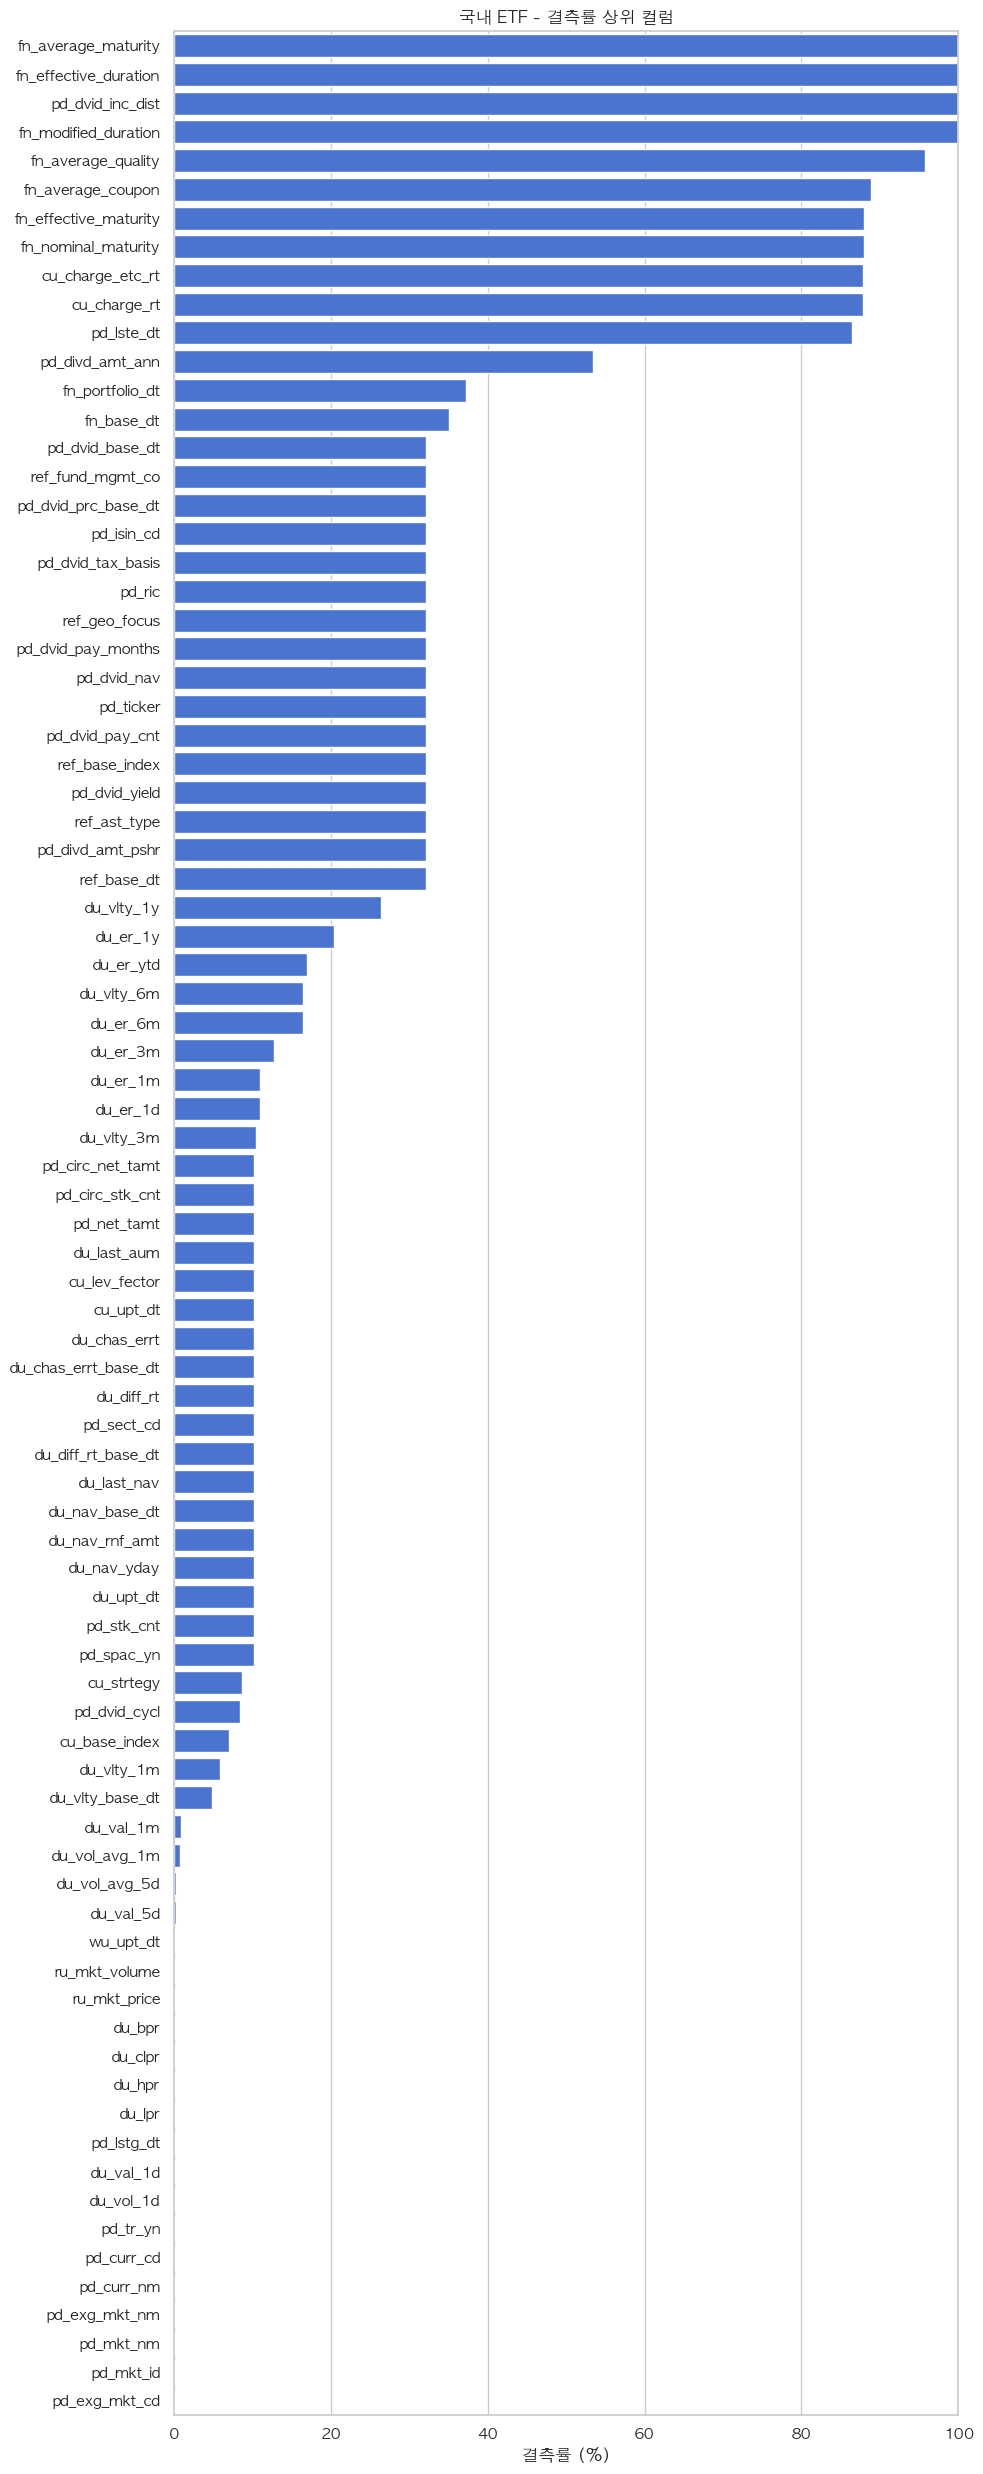

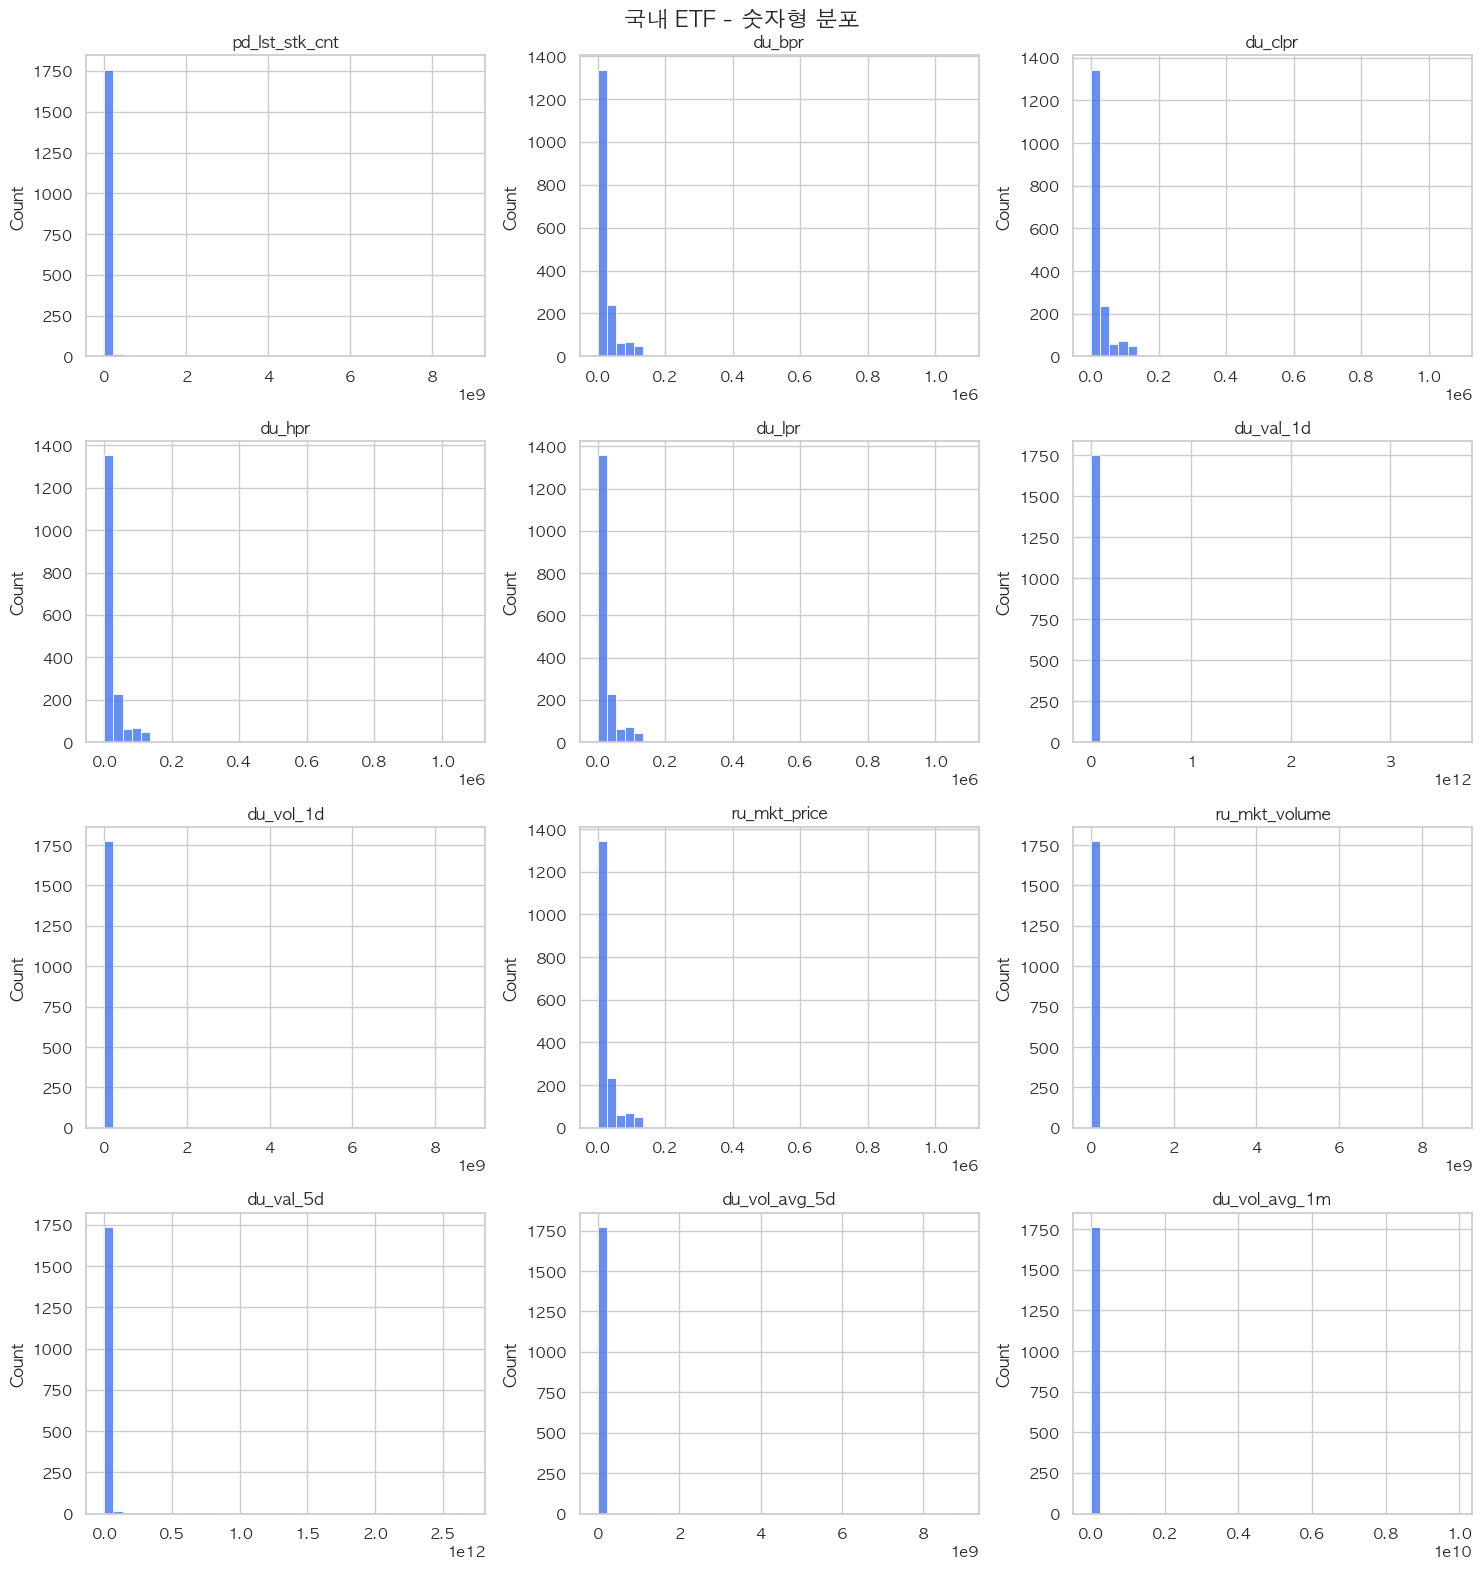

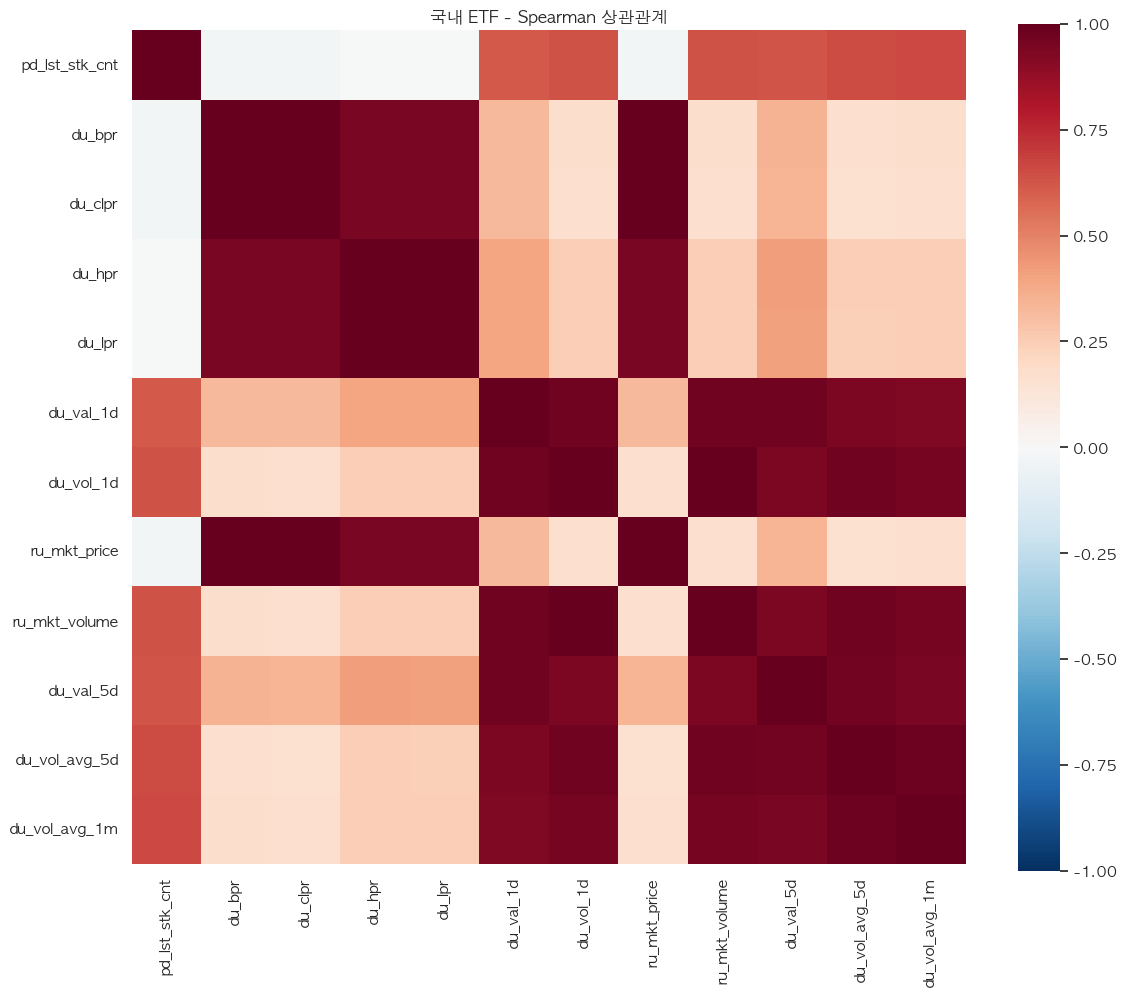

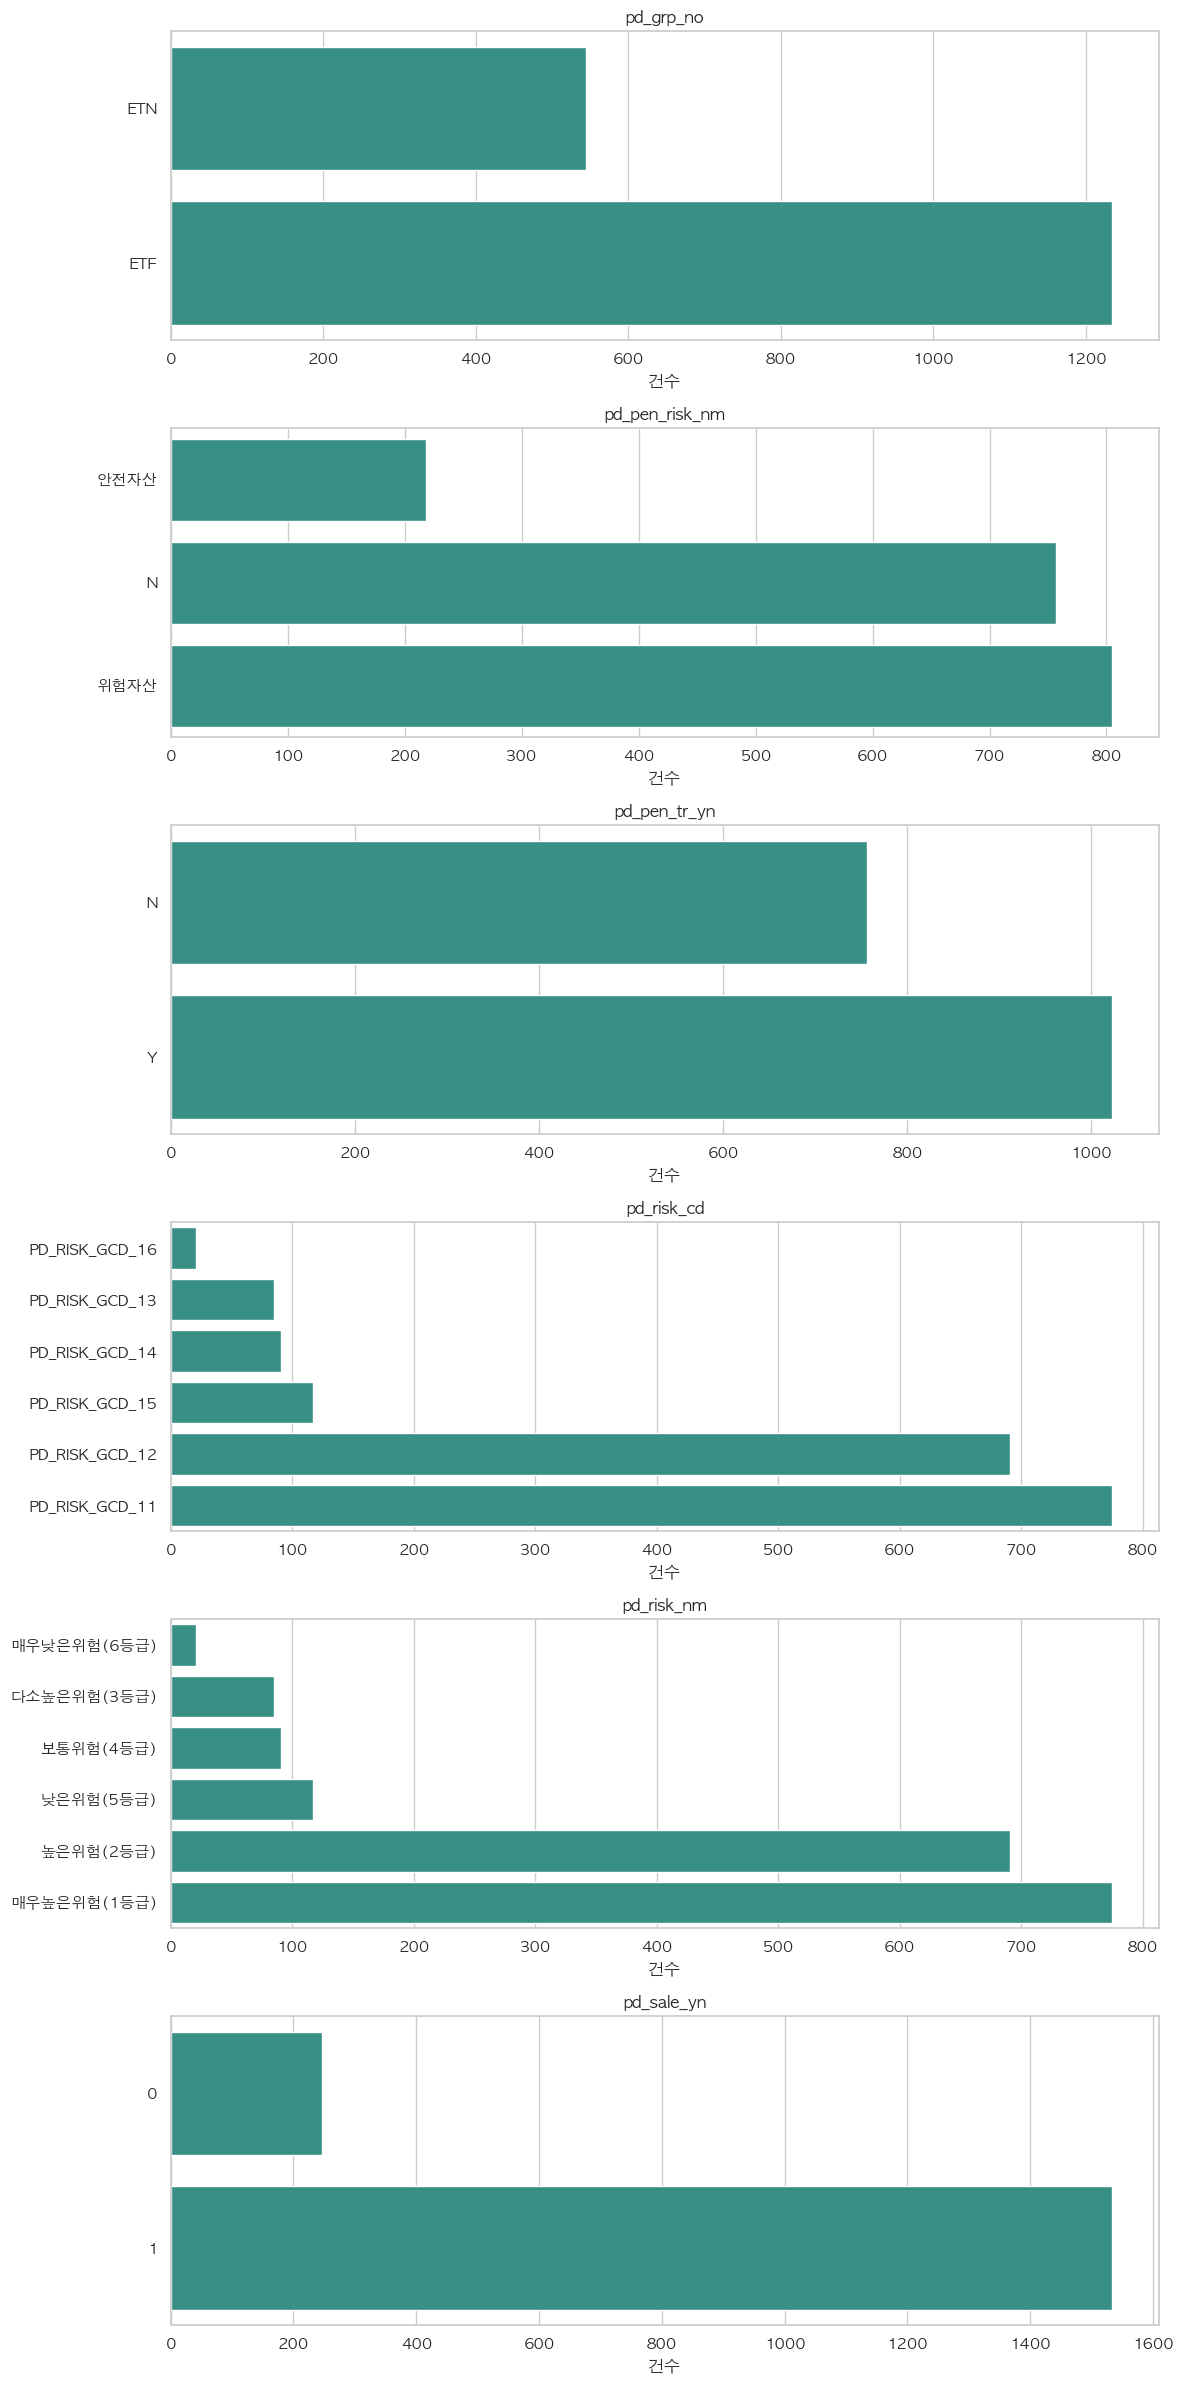

In [38]:
plot_product_eda(SELECTED_PRODUCT, df)

### 금융 지표 후보 요약

In [39]:
summary = finance_summary(df)
if summary.empty:
    print("자동 탐색된 금융 지표 후보가 없습니다.")
else:
    display(summary)

,count,mean,std,min,1%,25%,50%,75%,99%,max
ru_mkt_price,"1,776.0000","26,274.5890","56,967.6310",0.0000,0.0000,"8,245.0000","13,267.5000","26,265.0000","131,228.7500","1,075,450.0000"
du_diff_rt,"1,598.0000",11.1615,438.9011,-1.9000,-1.1218,-0.1100,0.0700,0.3500,2.7006,"17,545.2300"
du_last_aum,"1,598.0000","281,942,504,068.5125","1,197,104,718,215.7090",0.0000,0.0000,0.0000,"22,478,046,000.0000","124,377,424,750.0000","4,691,846,074,539.9941","25,834,235,404,500.0000"
du_last_nav,"1,598.0000","29,321.1055","59,386.5287",15.7400,971.9875,"9,790.7750","14,695.2650","29,816.2625","134,471.6568","1,075,530.8200"
du_nav_rnf_amt,"1,598.0000",-84.3403,940.0793,"-20,929.8000","-2,655.2621",-234.7125,-48.9250,39.3100,"2,547.2748","6,509.1000"
du_nav_yday,"1,598.0000","29,405.4457","59,313.8241",15.7400,973.6793,"9,864.2900","14,846.3000","30,160.3500","137,858.0569","1,075,321.4000"
pd_circ_net_tamt,"1,598.0000","141,503,303,758.1352","802,581,367,306.1753",0.0000,0.0000,0.0000,0.0000,"28,785,700,000.0000","2,486,160,499,999.9917","20,470,558,500,000.0000"
pd_net_tamt,"1,598.0000","296,536,677,085.0876","1,195,275,404,656.5208","89,477,660.0000","2,145,359,957.6900","12,625,251,207.7500","34,310,955,000.0000","143,528,121,273.7500","4,630,967,038,607.5850","25,474,813,891,225.0000"
pd_dvid_nav,"1,208.0000","31,592.6411","65,751.8220",48.3600,"1,407.8212","10,374.2475","15,585.5950","31,505.3750","121,608.8582","1,075,177.6600"
pd_dvid_yield,"1,208.0000",1.5865,3.1662,0.0000,0.0000,0.0669,0.6464,1.5648,18.5427,27.7832


## 4. 해외 ETF (`pref02n001`)

In [40]:
SELECTED_PRODUCT = "pref02n001"
df = datasets[SELECTED_PRODUCT]

print(f"상품군: {PRODUCTS[SELECTED_PRODUCT]} ({SELECTED_PRODUCT})")
print(f"형태: {df.shape[0]:,}행 × {df.shape[1]:,}열")
display(quality_flags(df))
display(df.head())

상품군: 해외 ETF (pref02n001)
형태: 6,037행 × 49열


,항목,개수
0,전체 결측 컬럼,0
1,결측률 90% 이상 컬럼,4
2,단일값 컬럼(결측 제외),13


,cu_base_index,cu_charge_rt,cu_etn_yn,cu_fund_mgmt_co,cu_index_repl_mthd,cu_index_tracking_yn,cu_inverse_short_yn,cu_lev_fector,cu_strtegy,cu_upt_dt,du_base_dt_match_yn,du_bpr,du_clpr,du_clpr_base_dt,du_clpr_src,du_diff_rt,du_er_1d,du_hpr,du_last_aum,du_last_nav,du_lpr,du_nav_base_dt,du_opr,du_upt_dt,du_val_1d,du_vol_1d,pd_abrv_nm,pd_curr_cd,pd_exg_mkt_cd,pd_grp_no,pd_isin_cd,pd_itm_no,pd_itm_no_ma,pd_lipper_id,pd_lstg_dt,pd_lst_price,pd_lst_stk_cnt,pd_mkt_id,pd_nm,pd_sale_yn,pd_trd_ccy,pd_tr_yn,pd_us_cik,ru_mkt_price,ru_mkt_volume,wu_core_yn,wu_inv_ast_type,wu_inv_rgn,wu_upt_dt
0,Index is not provided by Management Company,0.0900,<NA>,Empowered Funds LLC,<NA>,<NA>,<NA>,NaN,The Fund seeks to achieve long-term capital ap...,2026-08-22,N,58.2409,58.5084,2026-08-21,pd65n101.tday_clpr,NaN,0.4600,58.5084,"371,250,000.0000",NaN,58.4100,2026-08-22,58.4100,2026-08-22,"6,542.0000",112.0000,AAUA,USD,AMX,ETF,US02072Q2755,AAUA.K,AAUA.K,40306184,2026-03-18,0.0000,6320000,US,Alpha Architect US Equity 3 ETF,1,USD,0,1592900,58.5084,112.0000,<NA>,Equity,United States of America,2026-08-22
1,MSCI AC World ex USA NR USD,0.5400,<NA>,FCF Advisors LLC,<NA>,<NA>,<NA>,NaN,The Fund seeks to generate long-term returns i...,2026-08-22,N,31.8677,32.2603,2026-08-21,pd65n101.tday_clpr,NaN,1.2300,32.2603,"16,730,000.0000",NaN,32.2603,2026-08-22,32.2603,2026-08-22,"1,484.0000",46.0000,ABLG,USD,AMX,ETF,US89628W4015,ABLG.K,ABLG.K,40220923,2017-06-27,0.0000,525000,US,Abacus FCF International Leaders ETF,1,USD,0,1604813,32.2603,46.0000,<NA>,Equity,Global Ex US,2026-08-22
2,Russell 1000 Growth TR,0.3900,<NA>,American Century Investment Management Inc,<NA>,<NA>,<NA>,NaN,The Fund seeks capital appreciation. Under nor...,2026-08-22,N,68.8613,69.5811,2026-08-21,pd65n101.tday_clpr,NaN,1.0500,69.5811,"10,370,000.0000",NaN,69.5811,2026-08-22,69.5811,2026-08-22,"1,322.0000",19.0000,ACGR,USD,AMX,ETF,US0250723808,ACGR.K,ACGR.K,40232394,2021-06-29,0.0000,150000,US,American Century Large Cap Growth ETF,1,USD,0,1710607,69.5811,19.0000,<NA>,Equity,United States of America,2026-08-22
3,Index is not provided by Management Company,0.4500,<NA>,Corgi Strategies LLC,<NA>,<NA>,<NA>,2.0000,"The Fund seeks daily investment results, befor...",2026-08-22,N,11.3020,11.6112,2026-08-21,pd65n101.tday_clpr,NaN,2.7400,11.6112,"230,000.0000",11.5000,11.0800,2026-08-22,11.0800,2026-08-22,"1,019.0000",92.0000,ACLZ,USD,AMX,ETF,US21874K8493,ACLZ.K,ACLZ.K,40307130,2026-06-23,0.0000,20000,US,Corgi ACLS 2x Daily ETF,1,USD,0,2078265,11.6112,92.0000,<NA>,Alternatives,United States of America,2026-08-22
4,Index is not provided by Management Company,0.9300,<NA>,Harbor Capital Advisors Inc,<NA>,<NA>,<NA>,NaN,The Fund seeks total return. The Fund invests ...,2026-08-22,N,23.5121,23.7650,2026-08-21,pd65n101.tday_clpr,NaN,1.0800,23.7650,"6,460,000.0000",NaN,23.7050,2026-08-22,23.7100,2026-08-22,"18,686.0000",787.0000,ACOM,USD,AMX,ETF,US41151J5882,ACOM.K,ACOM.K,40307081,2026-06-16,0.0000,275000,US,Harbor Active Commodity ETF,1,USD,0,1860434,23.7650,787.0000,<NA>,Commodity,United States of America,2026-08-22


### 컬럼 프로파일과 스키마 설명

In [41]:
profile_columns = [
    "column", "description", "schema_type", "pandas_dtype", "nullable",
    "missing_count", "missing_pct", "unique_count",
    "mean", "median", "min", "max", "sample_values",
]
profile_columns = [
    column for column in profile_columns
    if column in profiles[SELECTED_PRODUCT].columns
]

profile_view = (
    profiles[SELECTED_PRODUCT][profile_columns]
    .sort_values(["missing_pct", "unique_count"], ascending=[False, False])
    .reset_index(drop=True)
)
display(profile_view)

,column,description,schema_type,pandas_dtype,nullable,missing_count,missing_pct,unique_count,mean,median,min,max,sample_values
0,du_diff_rt,종가 대비 추정 NAV 괴리율,"numeric(28,6)",float64,YES,6034,99.9500,3,20.8140,24.3120,4.2300,33.9000,4.23 | 24.312 | 33.9
1,cu_etn_yn,ETN 여부,text,string,YES,5972,98.9200,1,NaN,NaN,NaN,NaN,Y
2,wu_core_yn,핵심 ETF 여부,text,string,YES,5931,98.2400,1,NaN,NaN,NaN,NaN,N
3,cu_inverse_short_yn,인버스 또는 숏 여부,text,string,YES,5854,96.9700,1,NaN,NaN,NaN,NaN,Y
4,du_last_nav,추정 주당 NAV,"numeric(28,6)",float64,YES,5279,87.4400,529,"2,626.6193",26.7225,2.1250,"480,000.0000",11.5 | 24.9 | 134.121875
5,cu_lev_fector,배수,"numeric(18,6)",float64,YES,5136,85.0800,11,1.4363,2.0000,-3.0000,4.0000,2.0 | -2.0 | 3.0
6,cu_index_repl_mthd,인덱스 복제방법,text,string,YES,3630,60.1300,4,NaN,NaN,NaN,NaN,Full | Optimized | Swap
7,cu_index_tracking_yn,인덱스 추적 여부,text,string,YES,3630,60.1300,1,NaN,NaN,NaN,NaN,Y
8,du_last_aum,일간 순자산총액,"numeric(28,2)",float64,YES,205,3.4000,4899,"2,698,448,859.7394","76,740,000.0000",0.0000,"997,351,790,000.0000",371250000.0 | 16730000.0 | 10370000.0
9,pd_us_cik,미국 CIK,text,string,YES,18,0.3000,389,NaN,NaN,NaN,NaN,1592900 | 1604813 | 1710607


### 결측치·분포·상관관계·범주형 빈도

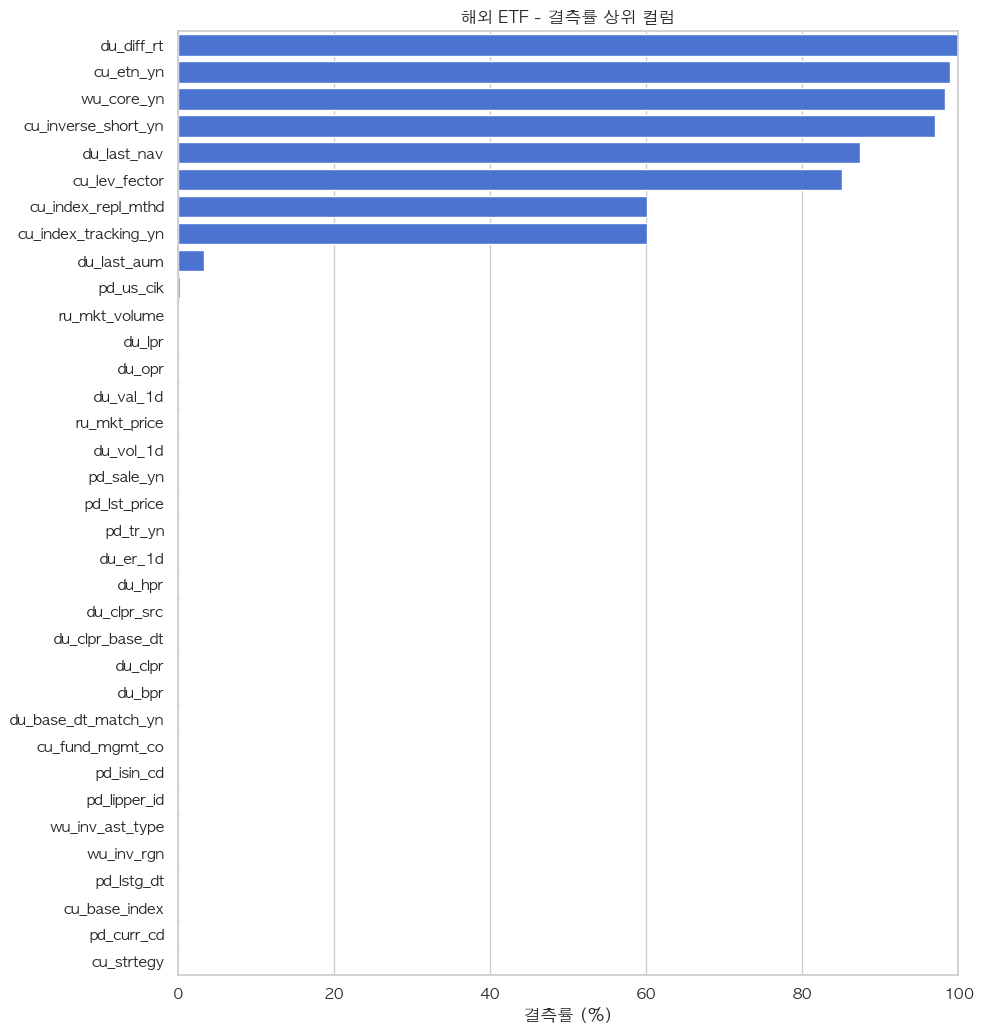

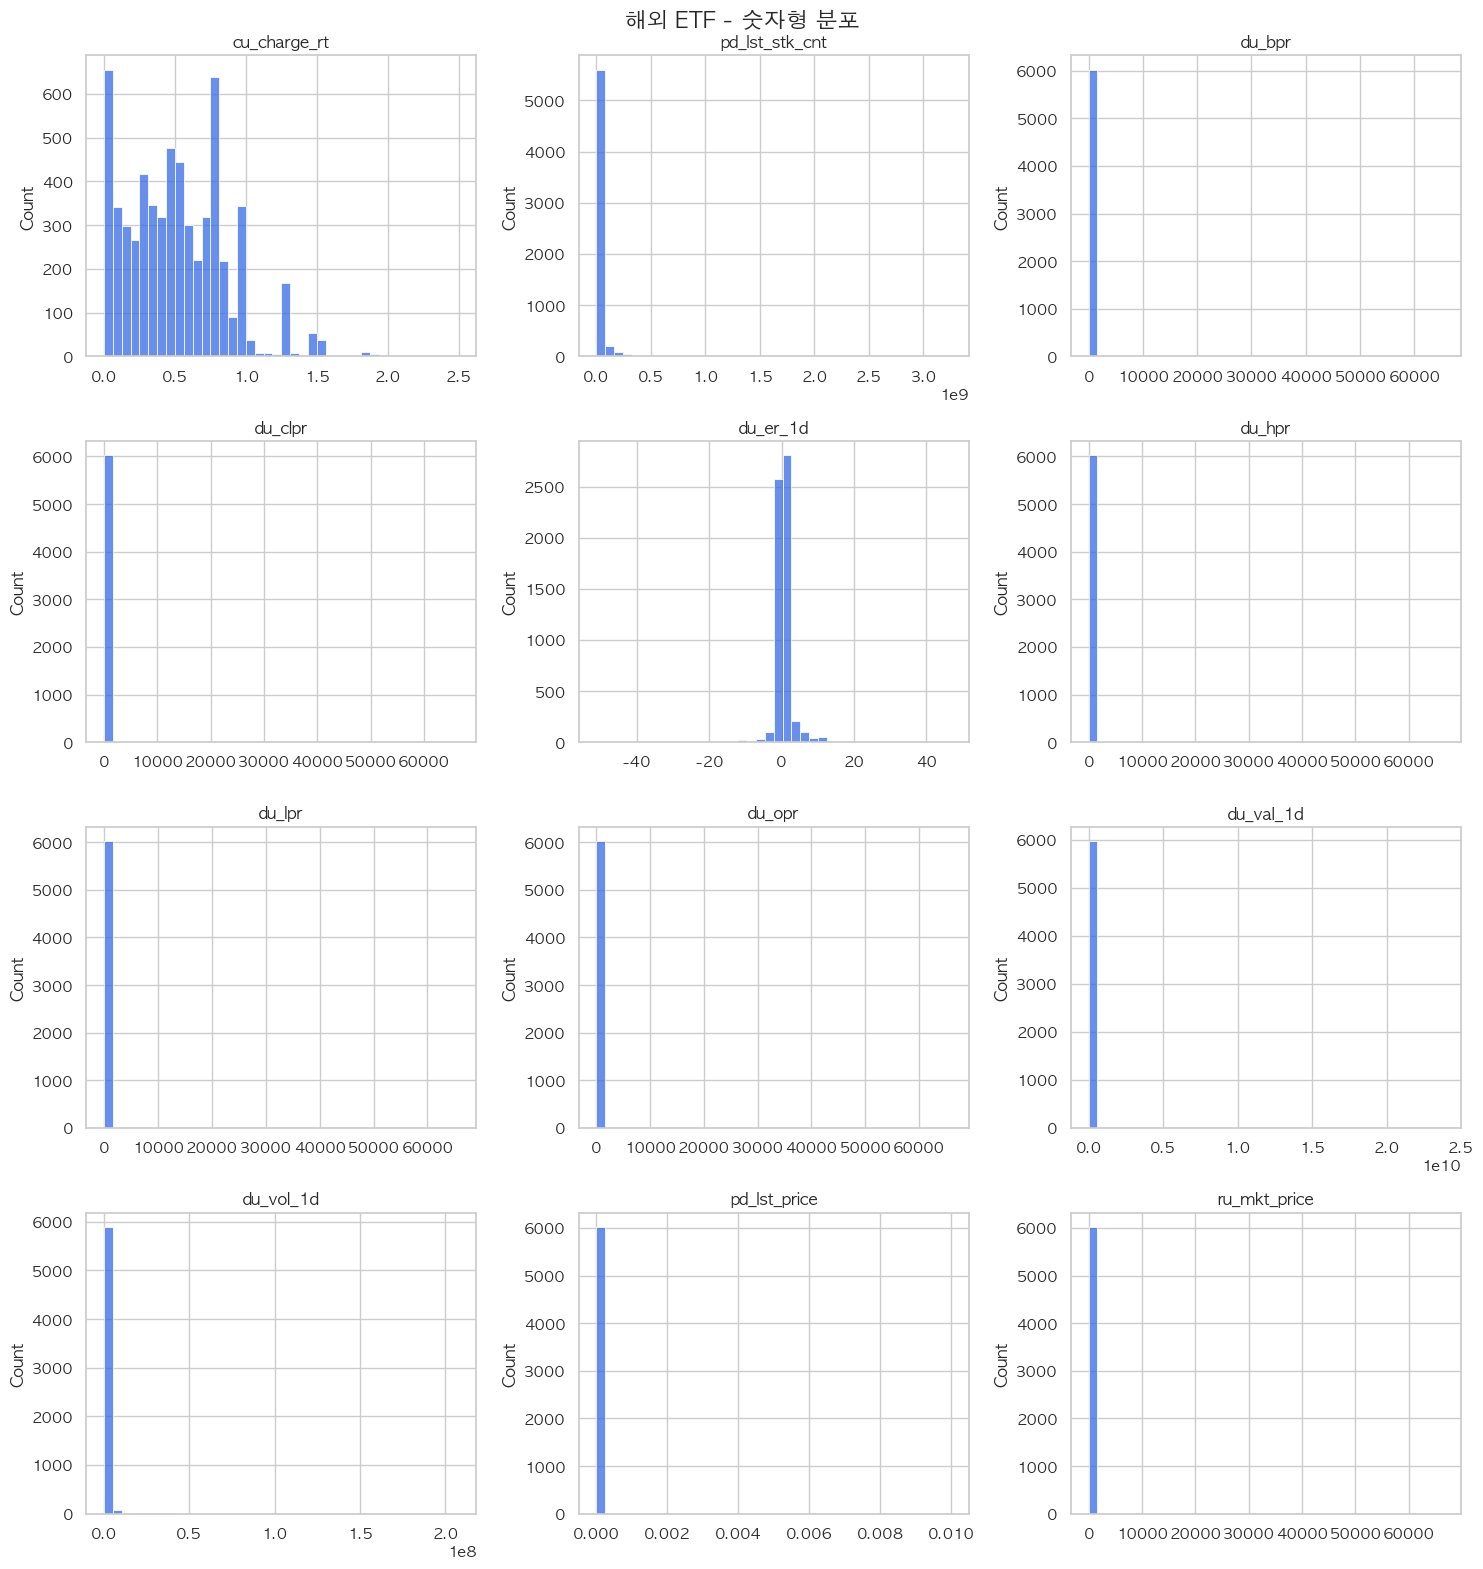

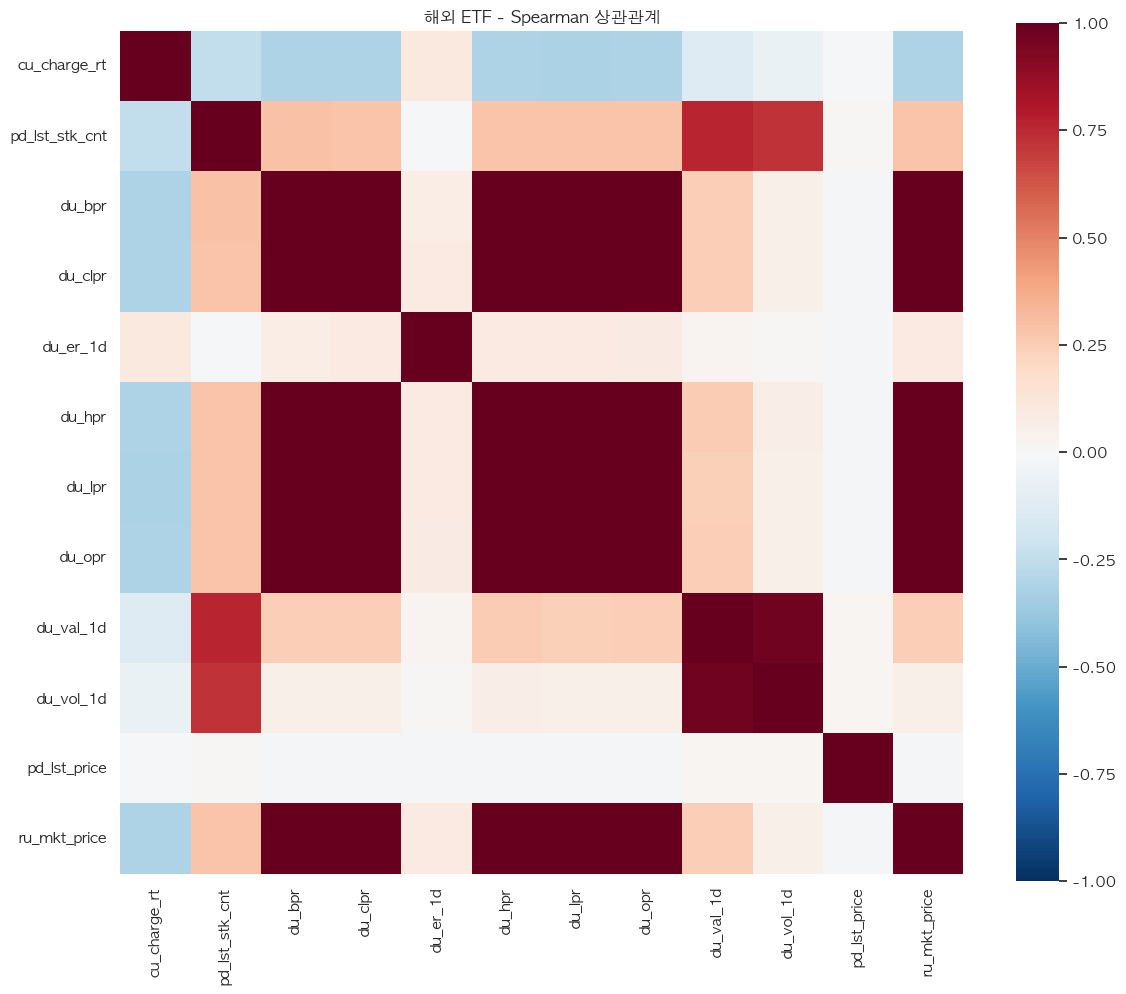

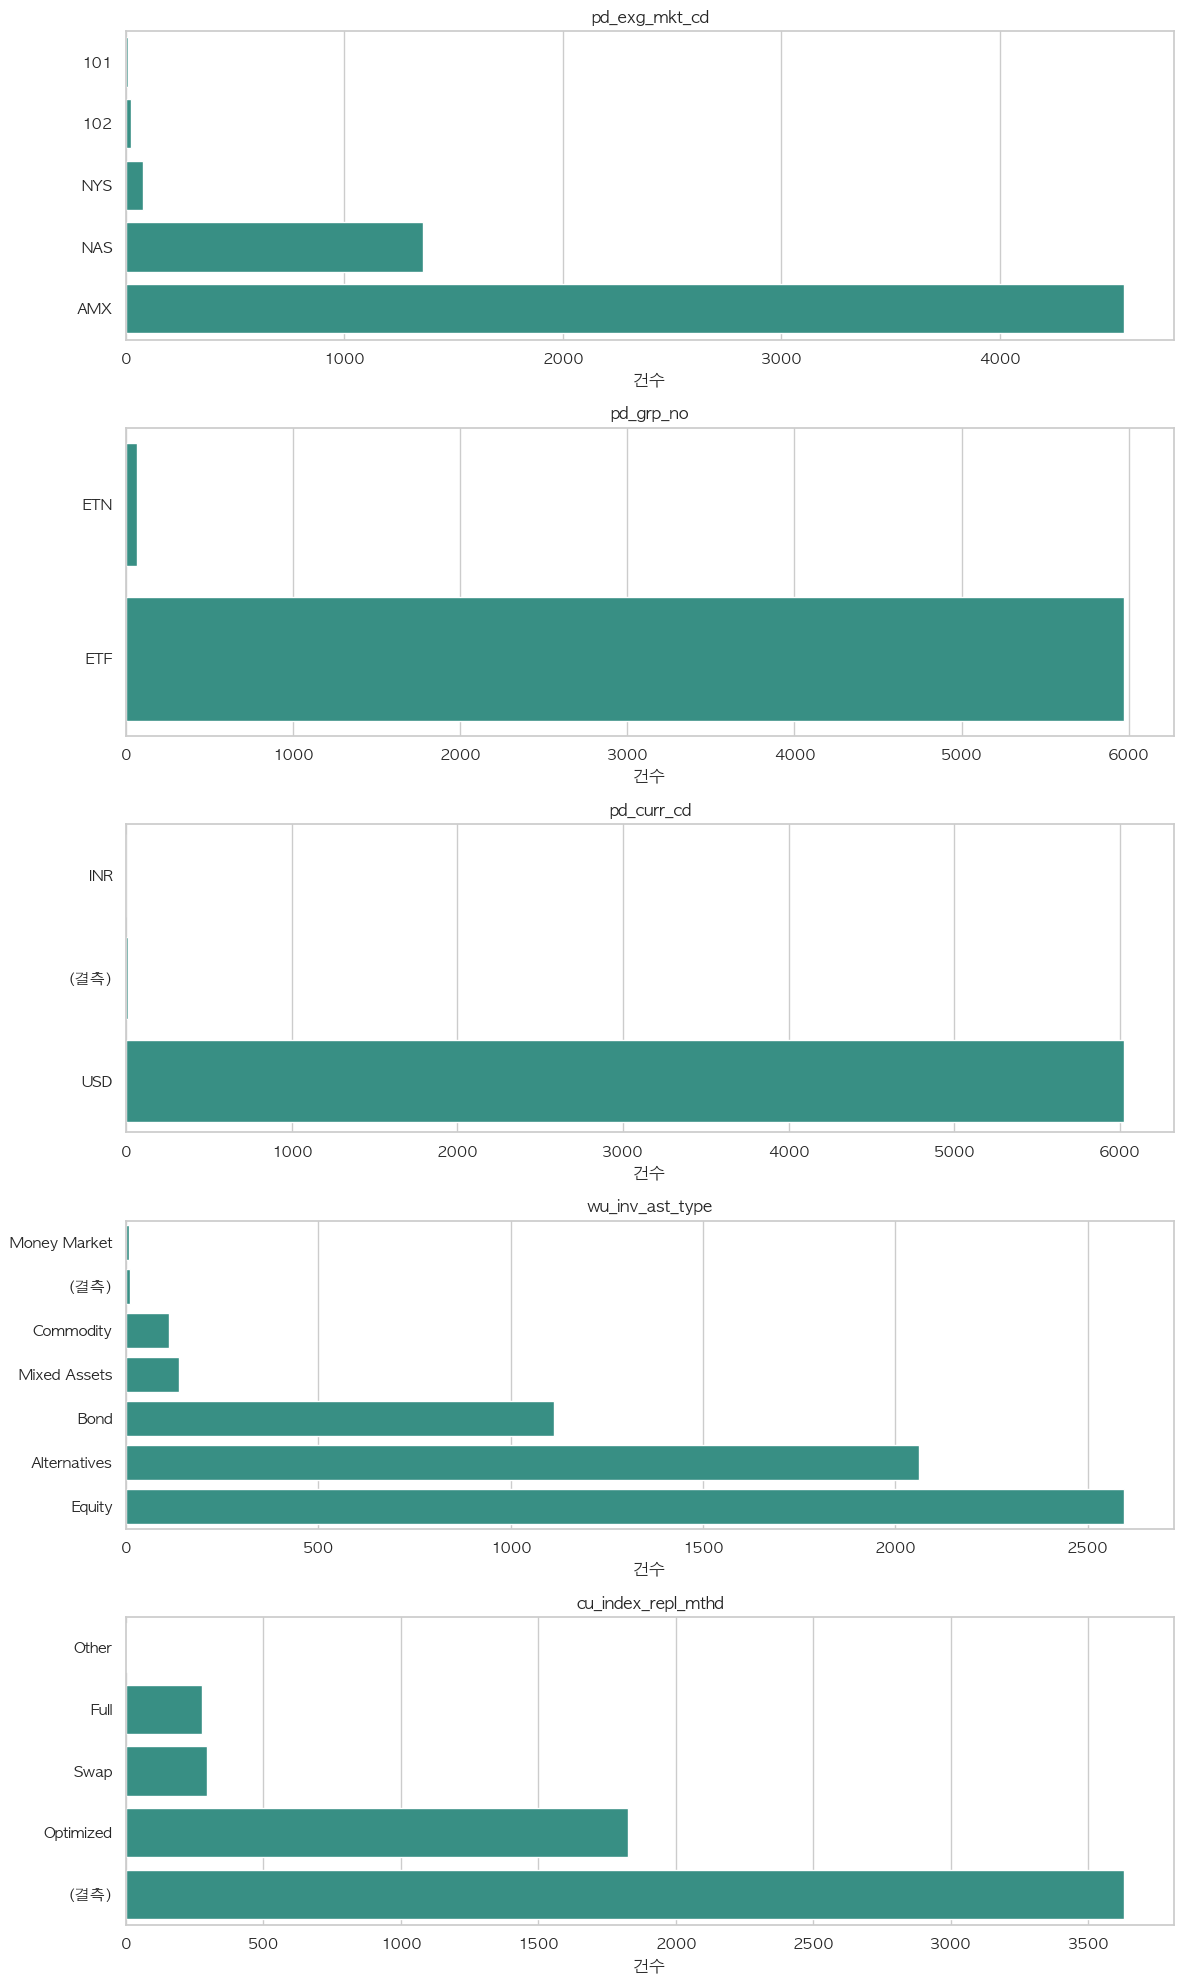

In [42]:
plot_product_eda(SELECTED_PRODUCT, df)

### 금융 지표 후보 요약

In [43]:
summary = finance_summary(df)
if summary.empty:
    print("자동 탐색된 금융 지표 후보가 없습니다.")
else:
    display(summary)

,count,mean,std,min,1%,25%,50%,75%,99%,max
cu_charge_rt,"6,037.0000",0.5069,0.3522,0.0000,0.0000,0.2200,0.4900,0.7500,1.4900,2.5000
pd_lst_price,"6,023.0000",0.0000,0.0001,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0100
ru_mkt_price,"6,023.0000",56.7936,857.3146,0.2842,5.1010,24.3725,32.7251,50.1774,239.1569,"66,480.0000"
du_last_aum,"5,832.0000","2,698,448,859.7394","25,560,491,306.0243",0.0000,"240,000.0000","12,705,000.0000","76,740,000.0000","466,017,500.0000","44,805,937,699.9997","997,351,790,000.0000"
du_last_nav,758.0000,"2,626.6193","34,360.3362",2.1250,6.0000,22.4417,26.7225,39.0900,182.1808,"480,000.0000"
du_diff_rt,3.0000,20.8140,15.1411,4.2300,4.6316,14.2710,24.3120,29.1060,33.7082,33.9000


## 5. 저장 결과

실행이 끝나면 현재 폴더의 `eda_output`에 다음 결과가 저장됩니다.

- `dataset_overview.csv`: 상품군별 크기·결측·중복·스키마 정합성
- `{상품코드}_column_profile.csv`: 전체 컬럼 프로파일과 스키마 설명
- `{상품코드}/missing_values.png`
- `{상품코드}/numeric_distributions.png`
- `{상품코드}/correlation_heatmap.png`
- `{상품코드}/categorical_frequencies.png`

In [44]:
saved_files = sorted(
    str(path.relative_to(DATA_DIR))
    for path in OUTPUT_DIR.rglob("*")
    if path.is_file()
)
print(f"저장 파일 수: {len(saved_files)}")
display(pd.DataFrame({"saved_file": saved_files}))

저장 파일 수: 21


,saved_file
0,eda_output/dataset_overview.csv
1,eda_output/prbd01n001/categorical_frequencies.png
2,eda_output/prbd01n001/correlation_heatmap.png
3,eda_output/prbd01n001/missing_values.png
4,eda_output/prbd01n001/numeric_distributions.png
5,eda_output/prbd01n001_column_profile.csv
6,eda_output/pref01n001/categorical_frequencies.png
7,eda_output/pref01n001/correlation_heatmap.png
8,eda_output/pref01n001/missing_values.png
9,eda_output/pref01n001/numeric_distributions.png
